### Librerías e Importaciones

In [212]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

import random
import copy
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Fuunciones Útiles

In [213]:
def codificacion_ciclica(df : pd.DataFrame, columna : str, periodo: int, eliminar_original: bool =False):
    """
    Codifica una columna numérica de forma cíclica usando seno y coseno.

    Parámetros:
    -----------
    df : pd.DataFrame - DataFrame que contiene la columna.
    columna : str - Nombre de la columna a transformar.
    periodo : int - Periodo del ciclo.
    eliminar_original : bool, default False - Si es True, elimina la columna original del DataFrame.

    Retorna:
    --------
    pd.DataFrame - DataFrame con las nuevas columnas '<columna>_sin' y '<columna>_cos'.
    """
    df = df.copy()

    # 2 * pi * valor / periodo
    radianes = 2 * np.pi * df[columna] / periodo

    df[f"{columna}_sin"] = np.sin(radianes)
    df[f"{columna}_cos"] = np.cos(radianes)

    if eliminar_original:
        df = df.drop(columns=[columna])

    return df

In [214]:
def resumen_outliers_iqr(df, columnas):
    """
    Calcula la media, los cuartiles (Q1, Q2, Q3), límites del IQR,
    porcentaje de outliers y métricas de forma (Skewness y Kurtosis).

    Parámetros:
    -----------
    df : pd.DataFrame - DataFrame que contiene las columnas.
    columnas : list - Lista con los nombres de las columnas a analizar.

    Retorna:
    --------
    pd.DataFrame - DataFrame de resumen detallado por columna.
    """
    resultados = []
    for col in columnas:

        # Estadísticos descriptivos básicos
        media = df[col].mean()
        q1 = df[col].quantile(0.25)
        q2 = df[col].median()  # Mediana
        q3 = df[col].quantile(0.75)

        # Rango Intercuartílico y Límites
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        # Conteo de Outliers
        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
        cantidad = len(outliers)
        porcentaje = (cantidad / len(df)) * 100

        # Métricas de forma - Skewness y Kurtosis
        skewness = df[col].skew()
        kurtosis = df[col].kurt()

        resultados.append({
            'Variable': col,
            'Media': round(media, 2),
            'Q1': round(q1, 2),
            'Q2': round(q2, 2),
            'Q3': round(q3, 2),
            'Skewness': round(skewness, 2),
            'Kurtosis': round(kurtosis, 2),
            'Límite Inf': round(limite_inferior, 2),
            'Límite Sup': round(limite_superior, 2),
            'Cant. Outliers': cantidad,
            '% Outliers': f"{porcentaje:.2f}%"
        })

    return pd.DataFrame(resultados)

### EDA

In [215]:
#Switch para trabajar en local o colab
entorno = 'Google Colab' if 'google.colab' in str(get_ipython()) else 'Local'
if entorno == 'Google Colab':
  !gdown 1y8wK9RincOHPtB20QL_Nb48ZBAUBAF65
data = pd.read_csv("Sample - Superstore.csv", sep=",")

Downloading...
From: https://drive.google.com/uc?id=1y8wK9RincOHPtB20QL_Nb48ZBAUBAF65
To: /content/Sample - Superstore.csv
100% 2.29M/2.29M [00:00<00:00, 122MB/s]


In [216]:
data.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Observamos los tipos de datos detectados automáticamente por Pandas y notamos que los campos temporales no están definidos como DateTime

In [217]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

Los campos 'Postal Code' y 'Row ID' son considerados identificadores únicos, por lo que los convertiremos a variables categóricas nominales.

In [218]:
data['Row ID'] = data['Row ID'].astype(str)
data['Postal Code'] = data['Postal Code'].astype(str)

In [219]:
print(f'Dataset - Cant. filas: {data.shape[0]}, Cant. columnas: {data.shape[1]}')


Dataset - Cant. filas: 9994, Cant. columnas: 21


Verificamos no tener valores faltantes, para ello contabilizamos los valores nulos por columna

In [220]:
data.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


#### Variables Numéricas

##### Distribuciones

Comenzamos nuestro análisis visualizando las distribuciones de las variables numéricas principales utilizando histogramas con curva KDE y boxplots para analizar asimetría y outliers.

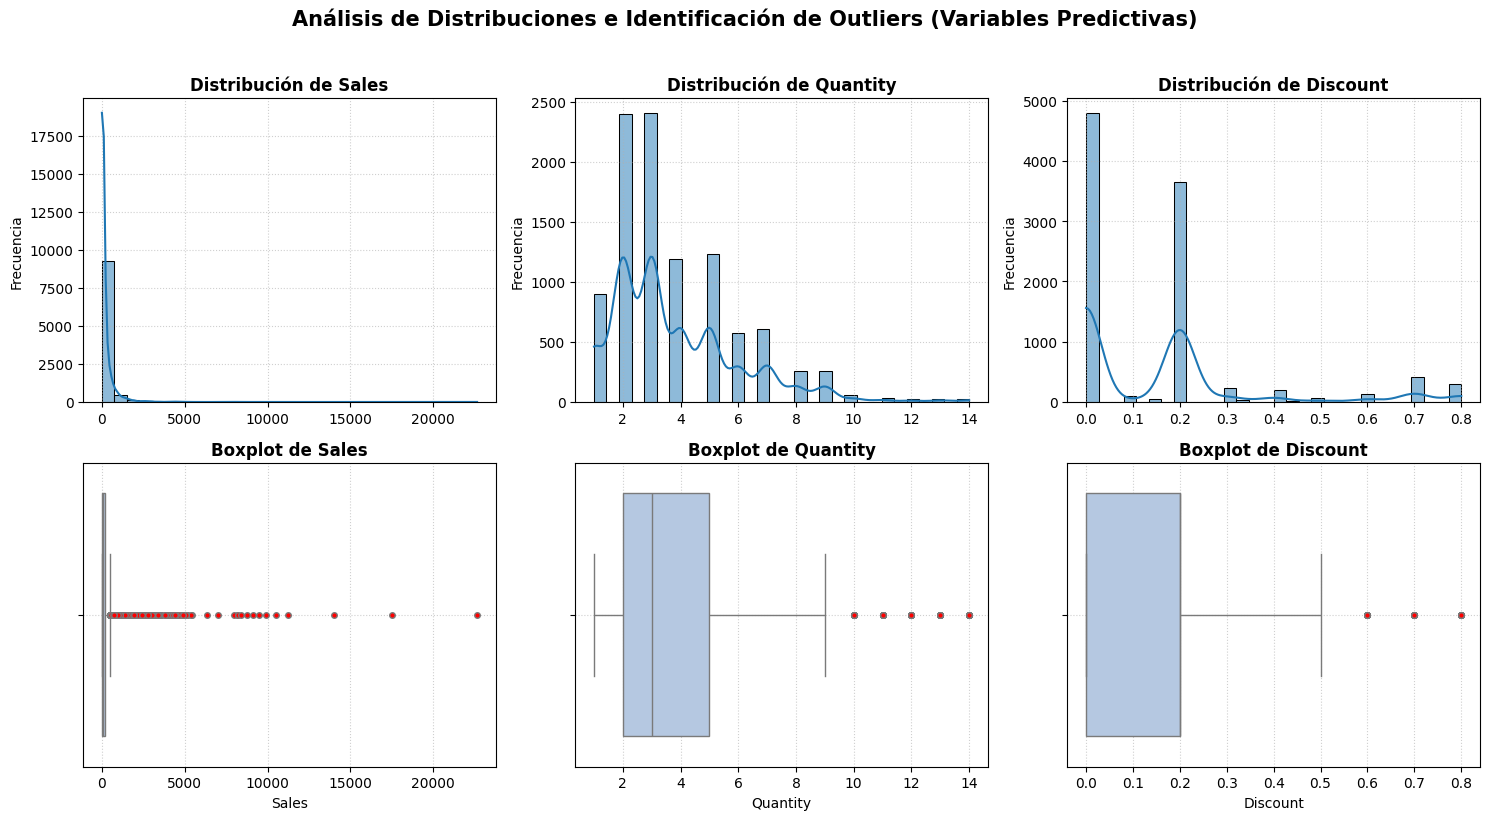

In [221]:
vars_dist = ['Sales', 'Quantity', 'Discount']

fig, axes = plt.subplots(2, len(vars_dist), figsize=(5 * len(vars_dist), 8))

for i, var in enumerate(vars_dist):
    # Histograma con curva KDE
    sns.histplot(data[var], kde=True, ax=axes[0, i], color='#1f77b4', bins=30)
    axes[0, i].set_title(f"Distribución de {var}", fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel("Frecuencia", fontsize=10)
    axes[0, i].grid(True, linestyle=':', alpha=0.6)

    # Boxplot para detectar asimetría y outliers
    sns.boxplot(x=data[var], ax=axes[1, i], color='#aec7e8', flierprops={'markerfacecolor': 'red', 'markersize': 4})
    axes[1, i].set_title(f"Boxplot de {var}", fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel(var, fontsize=10)
    axes[1, i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Análisis de Distribuciones e Identificación de Outliers (Variables Predictivas)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [222]:
resumen_outliers_iqr(data, vars_dist)

,Variable,Media,Q1,Q2,Q3,Skewness,Kurtosis,Límite Inf,Límite Sup,Cant. Outliers,% Outliers
0,Sales,229.86,17.28,54.49,209.94,12.97,305.31,-271.71,498.93,1167,11.68%
1,Quantity,3.79,2.00,3.00,5.00,1.28,1.99,-2.50,9.50,170,1.70%
2,Discount,0.16,0.00,0.20,0.20,1.68,2.41,-0.30,0.50,856,8.57%


**'Sales'** es una variable contínua que presenta una distribución asimétrica muy fuerte hacia la derecha (Skewness = 12.97).

La mayoría de las transacciones tienen un valor de venta menor a 2500 dólares. Podemos observar que no presenta outliers negativos ya que el valor de ventas está definido en el rango [0, inf], por lógica de negocio no podemos tener ventas negativas salvo que sean contrafacturas, que no están presentes en este dataset.

Es una distribución leptocúrtica (Kurtosis alta), es acumula la mayoría de sus observaciones cercano a la mediana, y posee una cola pesada a la derecha debido a los outliers. Presenta una gran cantidad de outliers positivos de gran magnitud (11.68%).

---

**'Quantity'** es una variable discreta, levemente sesgada a la derecha (Skewness = 1.28).

Concentra la mayoría de sus observaciones alrededor de las 2 y 3 unidades y decae para cantidades mayores a 3 unidades. No presenta outliers negativos ya que se trata de una variable discreta con dominio en los naturales y el cero, más específicamente en el rango [0 , 14].

Es una distribución leptocúrtica (Kurtosis > 0) unimodal, acumula la mayoría de sus observaciones cercano a la mediana (Q2 = 3), y posee una cola pesada a la derecha ya que los pedidos con grandes volúmenes son infrecuentes en el dataset.

Presenta una cantidad mínima de outliers positivos.

---
**'Discount'** es una variable continua acotada que presenta una distribución asimétrica positiva hacia la derecha (Skewness = 1.68).

Concentra la gran mayoría de sus observaciones en los valores 0.0 (0% de descuento) y 0.2 (20% de descuento). No presenta outliers negativos ya que el valor de descuento está acotado al rango [0, 0.8] ( 0 a 80% de descuento).

Es una distribución multimodal y platicúrtica (Kurtosis < 0), caracterizada por picos muy marcados en valores fijos de descuento (0 y 0.2) y una dispersión aplanada.

Los descuentos mayores o iguales al 60% son outliers y componen el ~9% de los registros totales.

---

A partir del análisis visual con boxplots, confirmamos que las observaciones atípicas representan transacciones reales y válidas dentro de la lógica del negocio (compras corporativas de alto volumen o promociones agresivas de liquidación). Por lo tanto, descartamos la eliminación o el truncamiento de estos valores.

Para mitigar la influencia de los valores atípicos sobre el aprendizaje de los modelos y preservar la escala de las características, se aplicará un escalado robusto, el cual utiliza la mediana y el rango intercuartílico en lugar de la media y la desviación estándar para la estandarización.

##### Correlación

Para determinar cuales de las variables numéricas intervienen directamente en la obtención de la variable objetivo 'Profit' decidimos consultar las matrices de correlación de Pearson y Spearman. Utilizando el método de Pearson determinamos si hay algún grado de asociación lineal entre las variables predictoras y la target, mientras que con el de Spearman determinamos la relación monotónica entre las mismas.

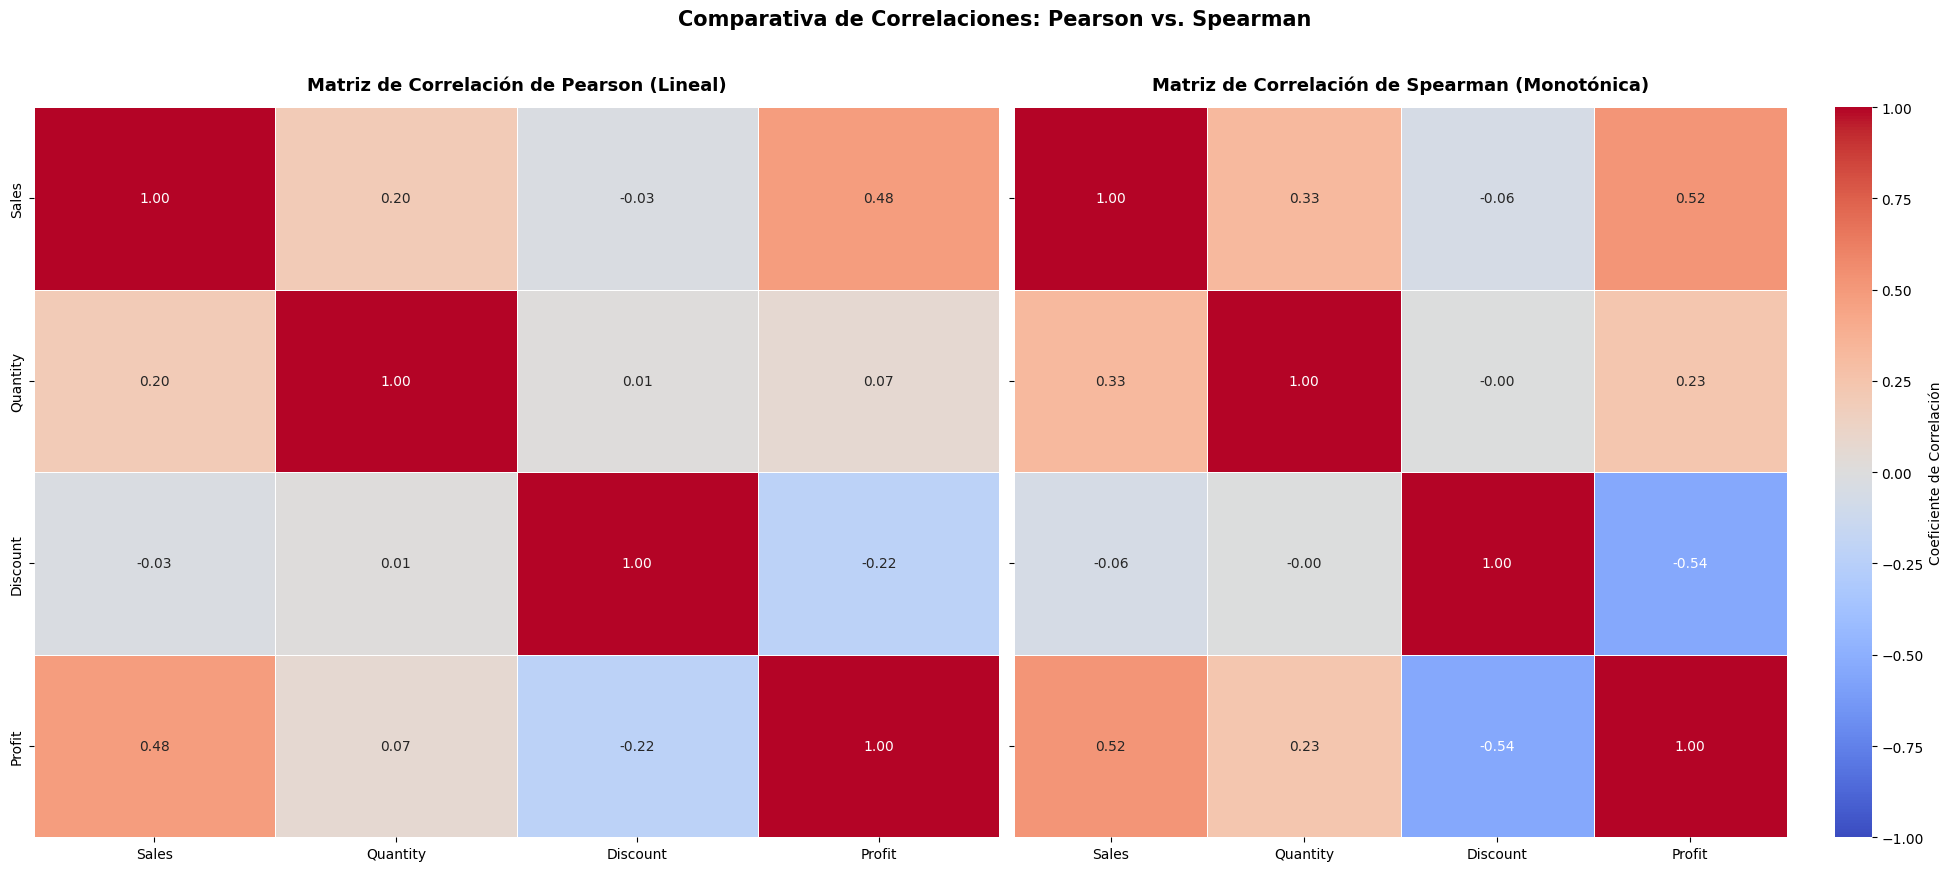

In [223]:
# Obtenemos las columnas numéricas
columnas_numericas = data.select_dtypes(include=[np.number]).columns

# Calculamos ambas matrices de correlación
corr_pearson = data[columnas_numericas].corr(method='pearson')
corr_spearman = data[columnas_numericas].corr(method='spearman')

# Graficamos ambas matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8.5), sharey=True)

# Heatmap Pearson
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Matriz de Correlación de Pearson (Lineal)", fontsize=13, fontweight='bold', pad=12)

# Heatmap Spearman
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación'},
    ax=axes[1]
)
axes[1].set_title("Matriz de Correlación de Spearman (Monotónica)", fontsize=13, fontweight='bold', pad=12)

plt.suptitle("Comparativa de Correlaciones: Pearson vs. Spearman", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**'Sales'** muestra una correlación lineal moderada y positiva (Pearson = 0.48) y una relación monotónica moderada creciente (Spearman = 0.52). Esto indica que a medida que se incrementa el volumen de ventas, la ganancia tiende a aumentar de manera consistente.

---

**'Quantity'** presenta una correlación lineal prácticamente nula (Pearson = 0.07), pero una relación monotónica débil creciente (Spearman = 0.23). La diferencia entre ambos coeficientes da a entender que hay presencia de una relación no lineal, indicando que un incremento en la cantidad de unidades vendidas tiende a aumentar levemente la ganancia.

---

**'Discount'** muestra una correlación lineal débil y negativa (Pearson= -0.22), pero una relación monotónica moderada decreciente significativamente más fuerte (Spearman = -0.52). Esta diferencia entre coeficientes da a entender que existe una relación no lineal entre la variable predictiva y la target. Los descuentos no reducen el margen de ganancias en una taza constante, un descuento leve puede llegar a mantener ganancias positivas, mientras que un descuento mayor puede reducirlas o hasta generar pérdidas.

##### Gráficos de dispersión

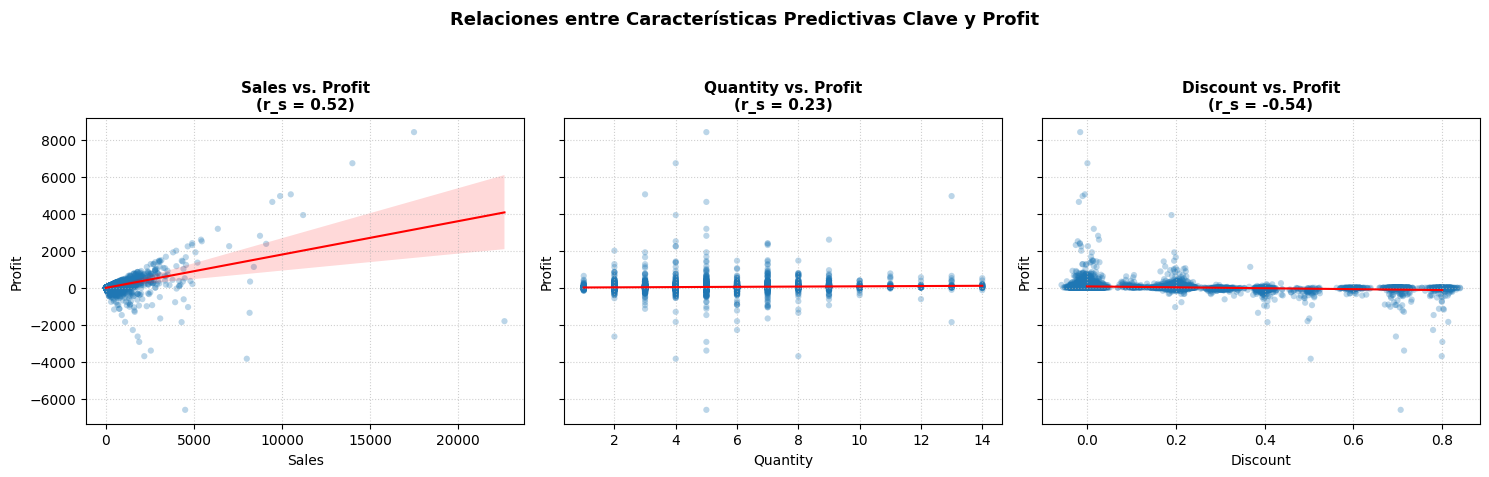

In [224]:
target = 'Profit'
correlaciones_target = corr_spearman[target].drop(target).sort_values(ascending=False)

# Seleccionamos las variables con mayor asociación de spearman (para captar Quantity)
variables_clave = correlaciones_target[correlaciones_target.abs() > 0.15].index.tolist()

#Generamos Gráficos de Dispersión con línea de tendencia
num_vars = len(variables_clave)

if num_vars > 0:
    fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 4.5), sharey=True)

    for ax, var in zip(axes, variables_clave):
        # Gráfico de dispersión con jittering si es la variable Discount
        # esto se realiza ya que la variable Discount es una variable numérica discreta
        # solamente sirve para la visualización
        if var == 'Discount':
            jitter = np.random.normal(0, 0.015, size=len(data))
            ax.scatter(data[var] + jitter, data[target], alpha=0.3, color='#1f77b4', edgecolors='none', s=20)
        else:
            ax.scatter(data[var], data[target], alpha=0.3, color='#1f77b4', edgecolors='none', s=20)

        # Línea de tendencia de referencia
        sns.regplot(x=var, y=target, data=data, ax=ax, scatter=False, color='red', line_kws={'linewidth': 1.5})

        ax.set_title(f"{var} vs. {target}\n(r_s = {correlaciones_target[var]:.2f})", fontsize=11, fontweight='bold')
        ax.set_xlabel(var, fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel(target, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Relaciones entre Características Predictivas Clave y {target}", fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se encontraron variables con |r_s| > 0.15 para graficar.")

El gráfico de **'Sales vs. Profit'** ilustra prácticamente un abanico. Para valores de ventas cercanos al cero, las ganancias convergen a cero. En cambio, cuanto más aumentan las ventas, mayor es la dispersión en ambas direcciones, en relación a la variable objetivo. Nos indica que cuanto mayor sea la venta, podemos ver grandes ganancias o exponernos a grandes pérdidas.

Podemos relacionarlo directamente con el gráfico de **'Discount vs. Profit'**. Se observa una tendencia marcada, si los descuentos son menores o iguales al %20, hay una buena probabilidad que nuestra venta termine generando ganancias. Si el valor de descuento es mayor al %20 ocurre lo contrario y nos exponemos a pérdidas.

Finalmente, el gráfico de **'Quantity vs. Profit'** confirma lo visto anteriormente. La distribución en columnas muestra que, sin importar cuántas unidades se vendan, la gran mayoría de las observaciones se concentran muy cerca de la línea de ganancia cero. Esto quiere decir que un alto volumen de unidades no garantiza rentabilidad por si solo.


#### Variables Categóricas

##### Funciones útiles

In [225]:
def graficar_top20_state_vs_profit(df, target="Profit"):
    # 1. Obtener los 20 estados con mayor cantidad de transacciones
    top20_states = df["State"].value_counts().head(20).index

    # Filtrar el dataframe para incluir solo estos 20 estados
    df_top20 = df[df["State"].isin(top20_states)].copy()

    # Ordenar los 20 estados por frecuencia
    order_freq = top20_states

    # Ordenar los mismos 20 estados según su mediana de Profit
    order_median = (
        df_top20.groupby("State")[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Panel 1: Frecuencia (Top 20)
    sns.countplot(
        data=df_top20,
        y="State",
        hue="State",
        order=order_freq,
        ax=axes[0],
        palette="Blues_r",
        legend=False,
    )
    axes[0].set_title(
        "Top 20 Estados por Volumen de Transacciones", fontweight="bold"
    )
    axes[0].set_xlabel("Cantidad de Transacciones")
    axes[0].set_ylabel("Estado")

    # Panel 2: Profit Mediano (Entre los Top 20)
    sns.barplot(
        data=df_top20,
        y="State",
        x=target,
        hue="State",
        order=order_median,
        ax=axes[1],
        estimator=pd.Series.median,
        palette="coolwarm",
        errorbar=None,
        legend=False,
    )
    axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_title(
        "Profit Mediano (USD) entre los Top 20 Estados", fontweight="bold"
    )
    axes[1].set_xlabel("Profit Mediano (USD)")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()


In [226]:
def graficar_categorica_vs_profit(df, feature, target="Profit"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. Orden por frecuencia (para la primera gráfica)
    order_freq = df[feature].value_counts().index

    # 2. Orden por mediana de Profit de mayor a menor (para la segunda gráfica)
    order_median = (
        df.groupby(feature)[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    # Gráfico 1: Frecuencia de registros
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        order=order_freq,
        ax=axes[0],
        palette="Blues_r",
        legend=False,
    )
    axes[0].set_title(f"Frecuencia de Registros por {feature}", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_ylabel("Cantidad de Transacciones")

    # Gráfico 2: Mediana de Profit (ordenada de mayor a menor)
    sns.barplot(
        data=df,
        x=feature,
        y=target,
        hue=feature,
        order=order_median,  # Usamos el orden por mediana descendente
        ax=axes[1],
        estimator=pd.Series.median,
        palette="coolwarm",
        errorbar=None,
        legend=False,
    )
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_title(
        f"Profit Mediano (USD) por {feature}",
        fontweight="bold",
    )
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_ylabel("Profit Mediano (USD)")

    plt.tight_layout()
    plt.show()

##### Criterios de Eliminación

Observamos las columnas disponibles para determinar cual de todas ellas intervienen en el cálculo de la variable objetivo **'Profit'**

In [227]:
columnas_categoricas = data.select_dtypes(exclude=[np.number]).columns

In [228]:
columnas_categoricas

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name'],
      dtype='object')

In [229]:
print(f'Cant. filas dataset: {data.shape[0]}')
for column in data[columnas_categoricas].columns:
    print(f'Val. Únicos para {column}: {len(data[column].unique())}')

Cant. filas dataset: 9994
Val. Únicos para Row ID: 9994
Val. Únicos para Order ID: 5009
Val. Únicos para Order Date: 1237
Val. Únicos para Ship Date: 1334
Val. Únicos para Ship Mode: 4
Val. Únicos para Customer ID: 793
Val. Únicos para Customer Name: 793
Val. Únicos para Segment: 3
Val. Únicos para Country: 1
Val. Únicos para City: 531
Val. Únicos para State: 49
Val. Únicos para Postal Code: 631
Val. Únicos para Region: 4
Val. Únicos para Product ID: 1862
Val. Únicos para Category: 3
Val. Únicos para Sub-Category: 17
Val. Únicos para Product Name: 1850


El criterio de eliminación de campos no predictivos será el siguiente:
- Los IDs por lo general representan valores únicos que no son significativos para realizar un cálculo de ganancias.
    - La única excepción podría llegar a ser 'Order ID' que nos permitiría agrupar y llegar a obtener valores representativos a cada transacción individual por cliente. Ej: La transacción con Order ID 1 tiene 2 registros, uno donde se compran 3 bibliotecas, otro donde se compran 2 celulares. Al agrupar por ID podemos obtener que se hizo una orden de 5 elementos, con una ganancia específica resultante de la suma de los dos registros. Ya que nuestra predicción será la variable objetivo 'Profit' por linea, es decir, por producto y no por orden, se desestima esta linea de pensamiento.

- El campo 'Product Name' es muy dificil de codificar en One-Hot Encoding ya que aumentaría la dimensionalidad del dataset de sobremanera. Además, contamos con agrupadores como 'Category' y 'Sub-Category' que serían útiles para captar tendencias de precios (Ej: Los articulos de electrónica tienden a tener precios mayores que los de bazar). Realizar Label Encoding no tiene sentido alguno por la introducción de jerarquías (Ej: El ID 500 es más grande que el ID 1)

- El campo 'Customer Name' no aporta información sobre el producto, solo sobre el cliente

- Los campos 'City' y 'Postal Code' tienen el mismo problema que 'Product Name', poseemos agrupadores en 'Region' y 'State'. En casos de alta granularidad como estos, podríamos llegar a tener muy pocos registros para una ciudad y código postal dado, lo que dificultaría que nuestro MLP pueda captar información relevante y sea propenso al overfitting.

- El campo 'Country' posee un solo valor único por lo que también puede ser descartado.

In [230]:
data = data.drop(columns=['Order ID', 'City', 'Postal Code', 'Country',
    'Product Name', 'Product ID', 'Row ID', 'Customer ID', 'Customer Name'])

##### Unificación de variable 'State'

Al realizar el desarrollo notamos que estabamos introduciendo dimensionalidad extra con la variable 'State'. Decidimos analizar la frecuencia por estado para determinar qué criterio podemos utilizar para unificar los estados menos frecuentes y reducir así el overfitting.

In [231]:
data['State'].value_counts()

,count
State,
California,2001
New York,1128
Texas,985
Pennsylvania,587
Washington,506
Illinois,492
Ohio,469
Florida,383
Michigan,255


Tomamos la decisión de realizar una agrupación de aquellos estados con ventas menores a 30 para evitar que nuestro modelo realice overfitting en los casos donde se presenten ventas de estos sectores.

Notamos que agrupar los estados con menos de 30 registros nos da un total de ~1.5% del total de los registros, previniendo que esta nueva categoría sea dominante sobre las otras. Es una decisión basada en heurística, sabiendo que con freciencias menores al umbral seleccionado los modelos son propensos a sobreajustarse.

In [232]:
umbral_ventas = 30
conteo_estados = data['State'].value_counts()
filtro_estados = conteo_estados[conteo_estados < umbral_ventas].index
data['State'] = data['State'].replace(filtro_estados, 'Other')
print(f'Estados unificados: {len(filtro_estados)}')
print(f'Other (%): {round(len(data[data['State'] == 'Other'])/len(data)*100,2)}')

Estados unificados: 11
Other (%): 1.4


##### Relaciones Variable vs. Profit

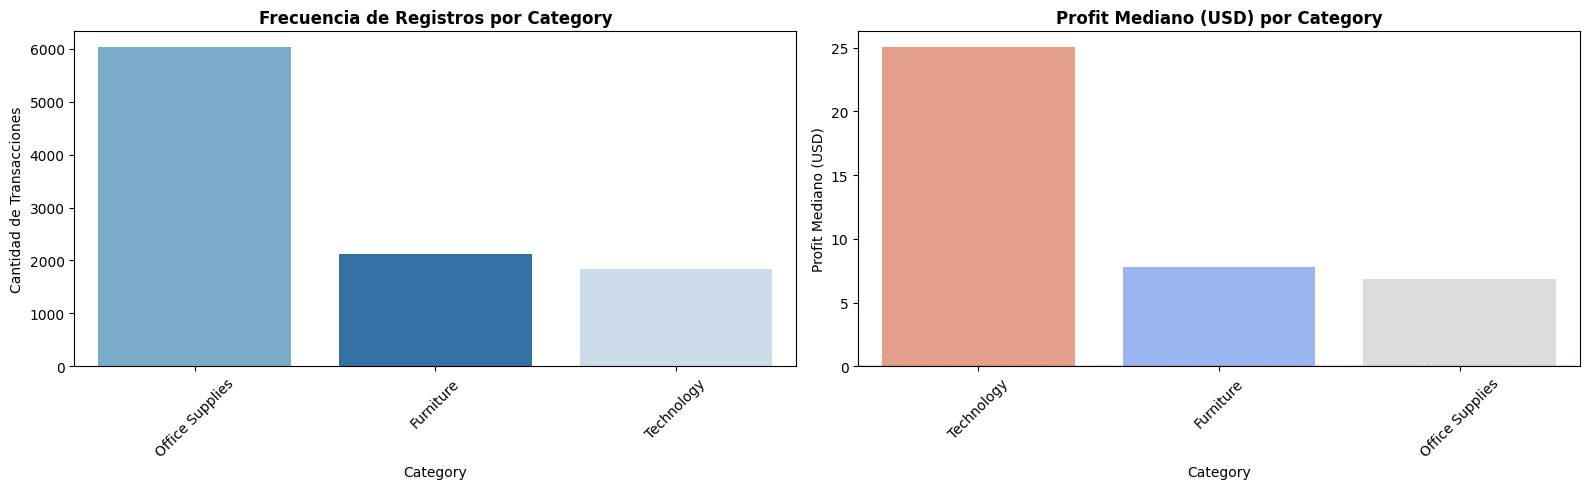

In [233]:
graficar_categorica_vs_profit(data, 'Category')

La categoría **Office Supplies** concentra la mayor cantidad de ventas, superando a **Furniture** y **Technology**. Sin embargo, al mirar la mediana de **Profit**, la relación cambia: **Technology** muestra la rentabilidad mediana más alta (~25 USD por venta), mientras que **Furniture** y **Office Supplies** presentan valores más bajos y parecidos entre sí, por debajo de los 8 USD.

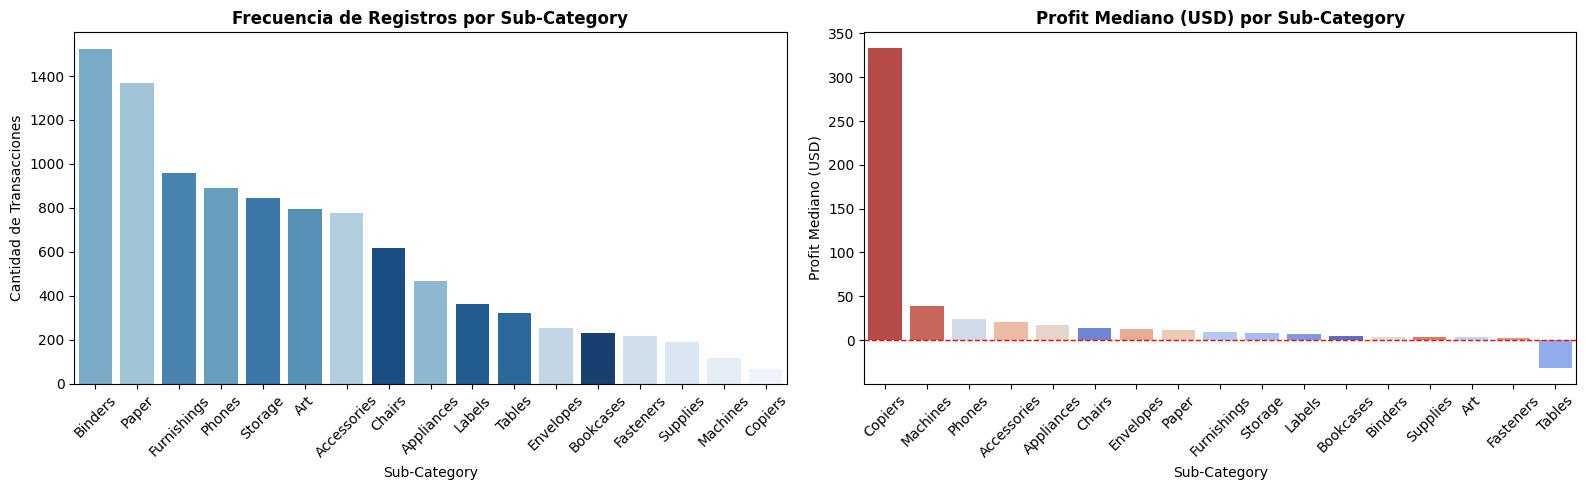

In [234]:
graficar_categorica_vs_profit(data, 'Sub-Category')

Las subcategorías **Binders**, **Paper** y **Furnishings** concentran la mayor cantidad de transacciones. Sin embargo, al contrastar este volumen con la mediana de **Profit**, se observa que ninguna de las tres representa un generador significativo de ganancia unitaria. En el extremo opuesto, **Copiers** se destaca como la subcategoría de mayor rentabilidad mediana, seguida por **Machines**, mientras que **Tables** se posiciona como la única subcategoría con una mediana de ganancia negativa.

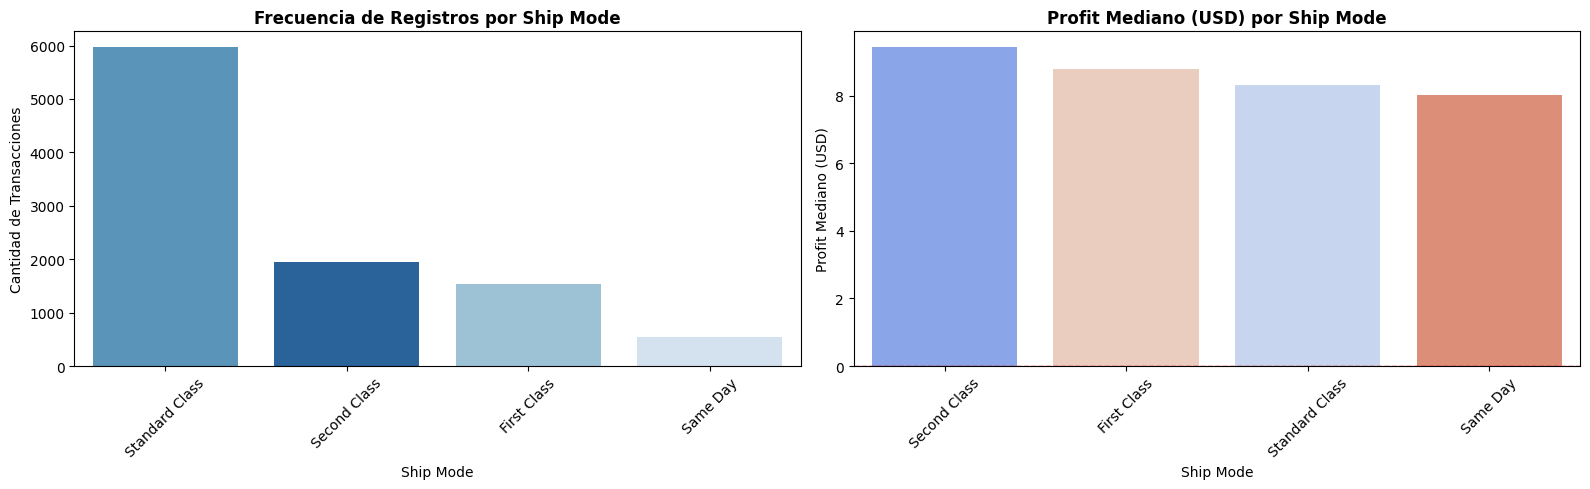

In [236]:
graficar_categorica_vs_profit(data, 'Ship Mode')

El modo de envío **Standard Class** concentra la mayor parte de las transacciones del dataset, por encima de opciones como **Second Class**, **First Class** y **Same Day**. Sin embargo, al mirar el gráfico de rentabilidad mediana, el comportamiento entre las cuatro opciones es bastante parejo, variando entre los 8 y 9.5 USD por venta. Second Class presenta la mediana más alta, mientras que Same Day tiene la más baja, lo que indica que la modalidad de envío no influye significativamente en la ganancia mediana.

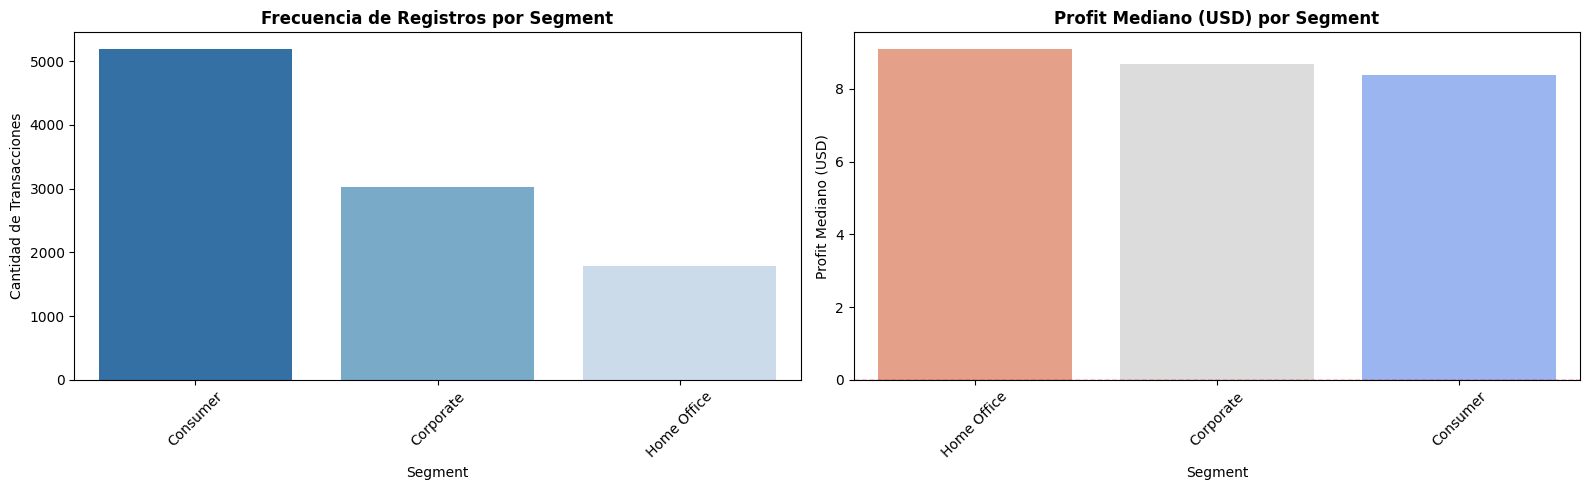

In [237]:
graficar_categorica_vs_profit(data, 'Segment')

El segmento **Consumer** concentra la mayor parte de las transacciones del dataset (más de 5,000 registros), seguido por **Corporate**  ( ~3,000 ) y **Home Office** con la menor cantidad de ventas ( ~1,800 ). Sin embargo, al analizar el gráfico de rentabilidad mediana, el comportamiento entre los tres segmentos es muy similar, ubicándose en un rango ajustado entre los 8 y 9 USD por venta. En este caso, **Home Office** presenta la mediana de ganancia levemente más alta ( ~9 USD ), mientras que **Consumer** registra la más baja ( ~8.4 USD ), lo que demuestra que el segmento de clientes tampoco genera variaciones significativas en el margen mediano de ganancia.

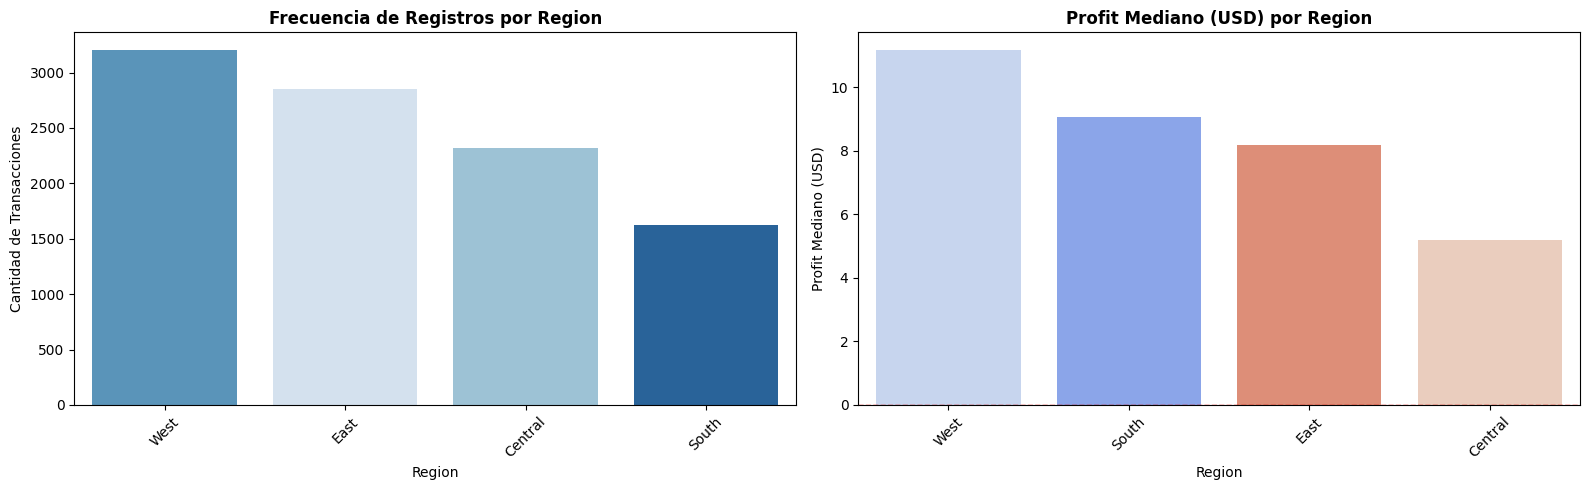

In [238]:
graficar_categorica_vs_profit(data, 'Region')

La región **West** lidera la cantidad de transacciones del dataset (más de 3,200 registros), seguida por **East** ( ~2,800 ), **Central** ( ~2,300 ) y **South** con la menor cantidad de ventas ( ~1,600 ). Al observar el gráfico de rentabilidad mediana, se perciben diferencias más marcadas entre regiones: **West** también encabeza la ganancia mediana alcanzando los ~11 USD por venta, seguida por **South** ( ~9 USD ) y **East** ( ~8 USD ). En el extremo opuesto, **Central** registra la mediana más baja ( ~5 USD ), mostrando un margen de ganancia menor al del resto de las regiones.

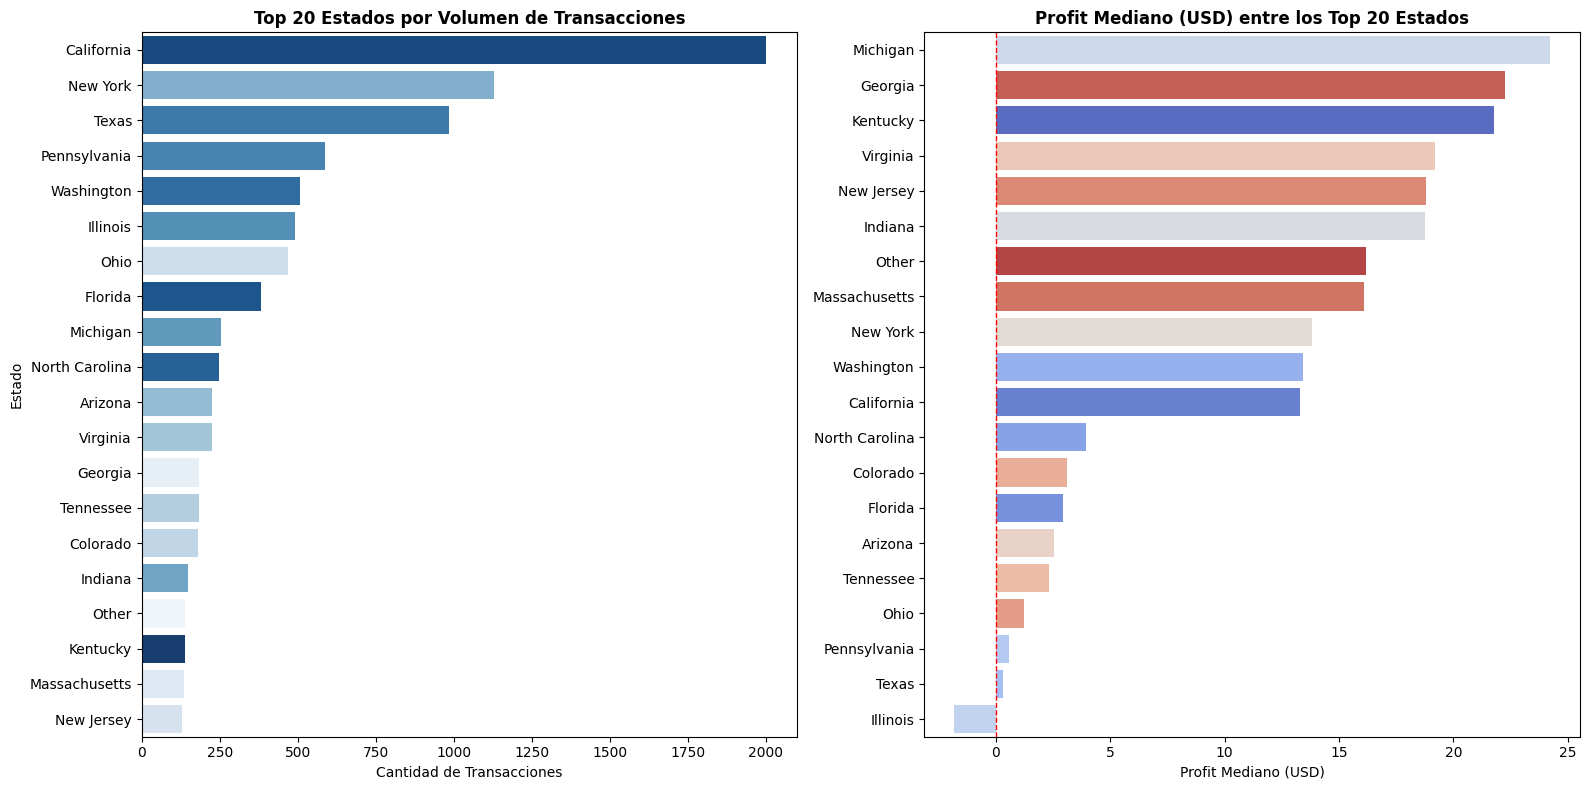

In [239]:

graficar_top20_state_vs_profit(data)

Los estados de **California**, **New York** y **Texas** encabezan con claridad la cantidad de transacciones dentro del top 20. Sin embargo, al observar el gráfico de rentabilidad mediana, se observa disparidad entre el volumen de ventas y el margen operativo: estados con menor cantidad de registros como **Michigan**, **Georgia** y **Kentucky** alcanzan las medianas de Profit más altas ( ~20 a 24 USD por venta ). En contraste, mercados de gran volumen como **Texas** e **Illinois** muestran un desempeño desfavorable, registrando medianas cercanas a cero o negativas en el caso de Illinois. Por su parte, la categoría agrupada **Other** exhibe un rendimiento mediano competitivo ( ~16 USD ), lo que confirma que reunir los estados con bajo volumen transaccional conserva una señal de margen relevante.

#### Variables Temporales (datetime)

##### Feature engineering

Decidimos extraer la diferencia entre la fecha de orden y la de envío para obtener así un valor representativo a la urgencia con la que se entrega el pedido. Por lo general, cuanto más corta sea la espera entre el momento donde se realiza la orden y el envío, supondría un costo mayor para el cliente, lo que se traduce en un aumento de ganancias.

In [240]:
#Al ser campos datetime, podemos directamente restar ambos campos y extraer el número de días
data['dias_hasta_envio'] = (data['Ship Date'] - data['Order Date']).dt.days

#Ya que el valor previamente calculado nos sirve para recrear Ship Date, podemos eliminar esta columna.
#De esta manera también eliminamos redundancia de datos.
data = data.drop(columns=['Ship Date'])

A continuación extraemos los datos relevantes del campo 'Order Date'. Utilizamos 'Order Date' para la extracción ya que representa el momento exacto donde se realizó la compra, lo que refleja mejor las tendencias estacionales en general. Por ejemplo, en diciembre se vería un incremento de ventas por Navidad. Una vez extraídos los datos, se elimina la columna original para evitar redundancia de información.

In [241]:
data['mes'] = data['Order Date'].dt.month
data['dia_semana'] = data['Order Date'].dt.dayofweek
data['trimestre'] = 'Q' + data['Order Date'].dt.quarter.astype(str)
data['anio'] = data['Order Date'].dt.year.astype(str)
data = data.drop(columns=['Order Date'])

Finalmente, decidimos tratar el campo año como variable categórica ya que el valor de la variable objetivo no guarda relación con el valor numérico del año. Que el valor de un año aumente una unidad no debería porqué resultar en un incremento o decremento de la ganancia. Por lo general, este tipo de tendencias dependen de factores externos como la economía del país, políticas que soporten la venta de esos productos en específico, impuestos, entre otros.

In [242]:
data['anio'] = data['anio'].astype(str)

##### Relaciones Variable vs. Profit

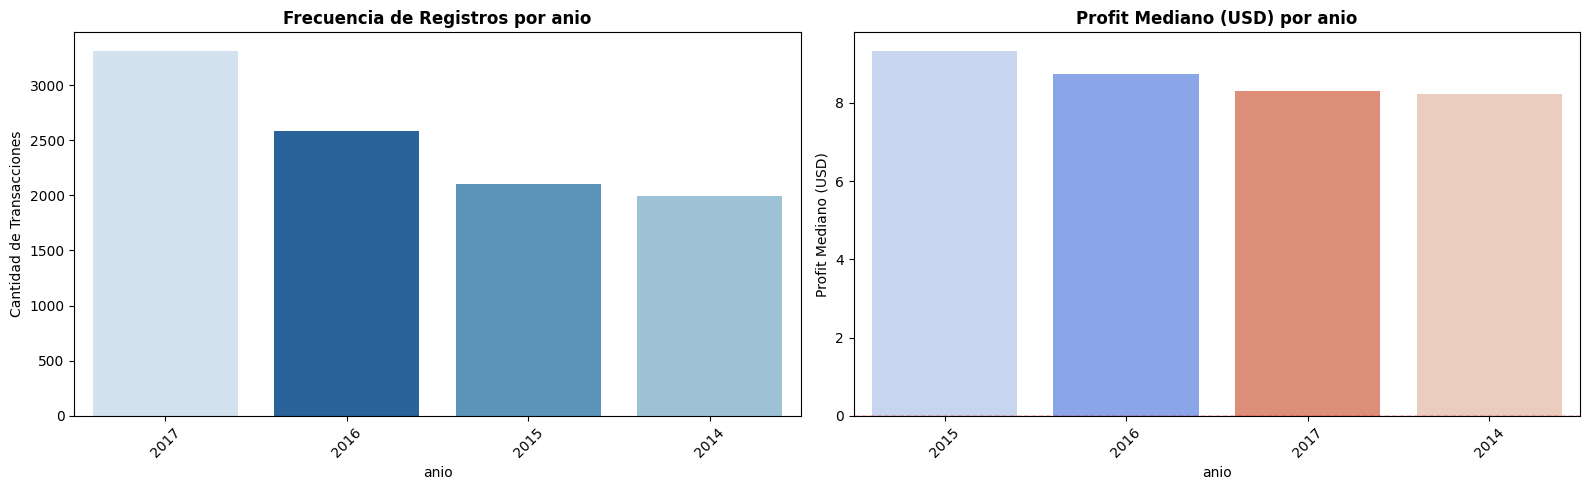

In [243]:
graficar_categorica_vs_profit(data, 'anio')

El volumen de transacciones muestra un crecimiento constante año a año, alcanzando su punto más alto en 2017 (más de 3,300 registros), seguido por 2016 ( ~2,600 ), 2015 ( ~2,100 ) y 2014 con la menor cantidad de operaciones ( ~2,000 ). Sin embargo, al analizar la rentabilidad mediana, el comportamiento se mantiene sumamente estable a lo largo del tiempo, ubicándose en un rango muy estrecho entre los 8 y 9.5 USD por venta. El año 2015 registra la mediana levemente superior ( ~9.3 USD ), mientras que 2014 y 2017 presentan los valores más bajos ( ~8.2 USD ), lo que demuestra que el incremento en el volumen operativo no alteró significativamente el margen mediano de ganancia por transacción.

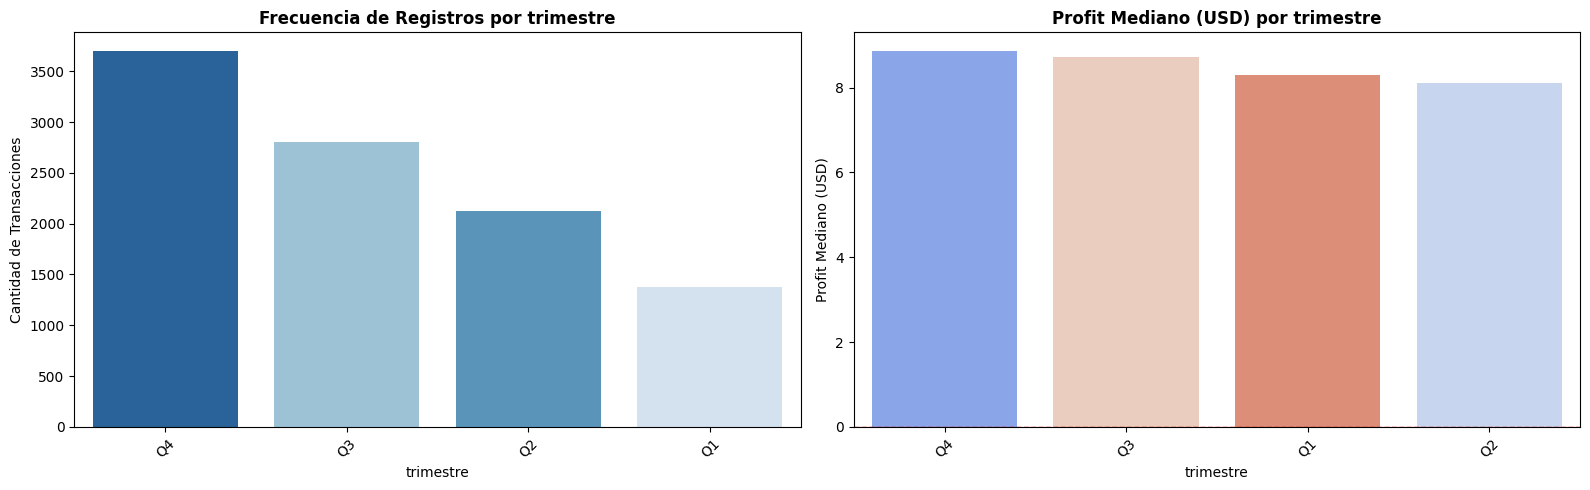

In [244]:
graficar_categorica_vs_profit(data, 'trimestre')

El **cuarto trimestre** concentra la mayor cantidad de transacciones del dataset (más de 3,600 registros), seguido por **Q3** ( ~2,800 ), **Q2** ( ~2,100 ) y **Q1** con la menor actividad comercial ( ~1,400 ). Sin embargo, al observar el gráfico de rentabilidad mediana, el comportamiento se mantiene homogéneo a lo largo del año, variando en un rango muy estrecho entre los 8.1 y 8.9 USD por venta. **Q4** registra la mediana de ganancia levemente más alta ( ~8.9 USD ), mientras que **Q2** presenta la más baja ( ~8.1 USD ), lo que confirma que la estacionalidad trimestral impacta principalmente en el volumen operativo y no en el margen mediano de ganancia por transacción.

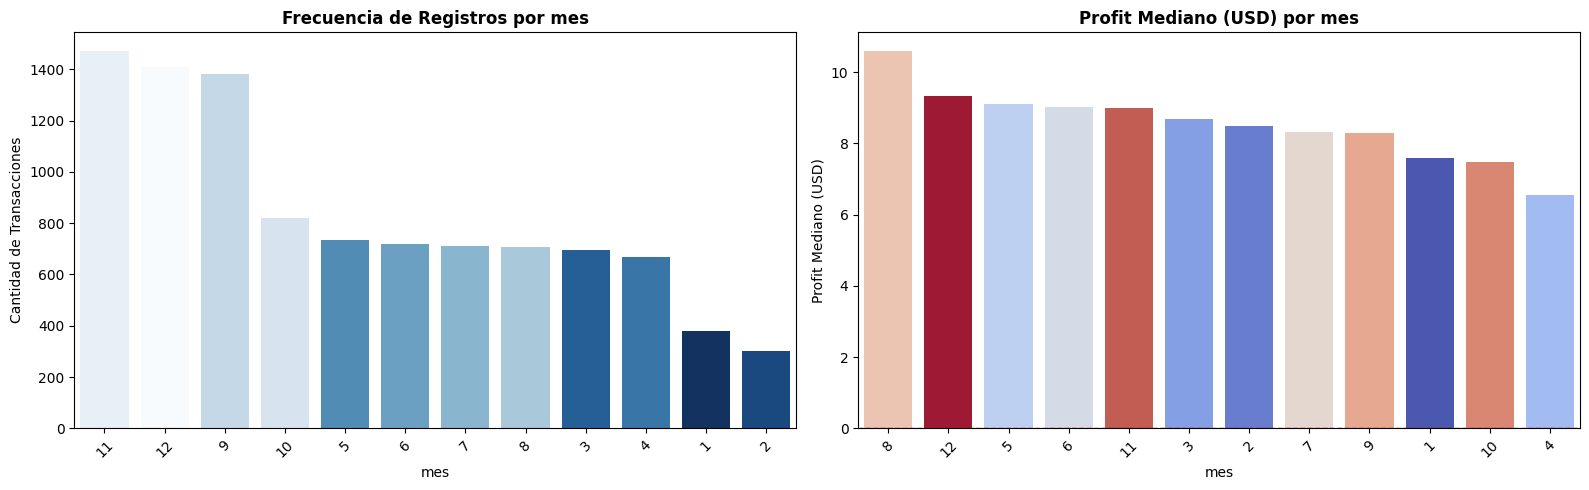

In [245]:
graficar_categorica_vs_profit(data, 'mes')

Los meses de fin de año como **septiembre, noviembre y diciembre** concentran la mayor cantidad de ventas (alrededor de 1,400 registros cada uno), mientras que los primeros meses como **enero y febrero** muestran el menor volumen transaccional ( ~300 a 400 ventas ). En cuanto a la rentabilidad mediana, los valores se mantienen bastante estables entre los 6.5 y 10.5 USD por venta. El mes de **agosto** encabeza el margen mediano ( ~10.6 USD ) seguido por **diciembre** ( ~9.4 USD ), mientras que el mes **abril** registra el valor más bajo ( ~6.5 USD ), lo que confirma que la concentración de ventas hacia el cierre de año no modifica drásticamente el margen mediano mensual.

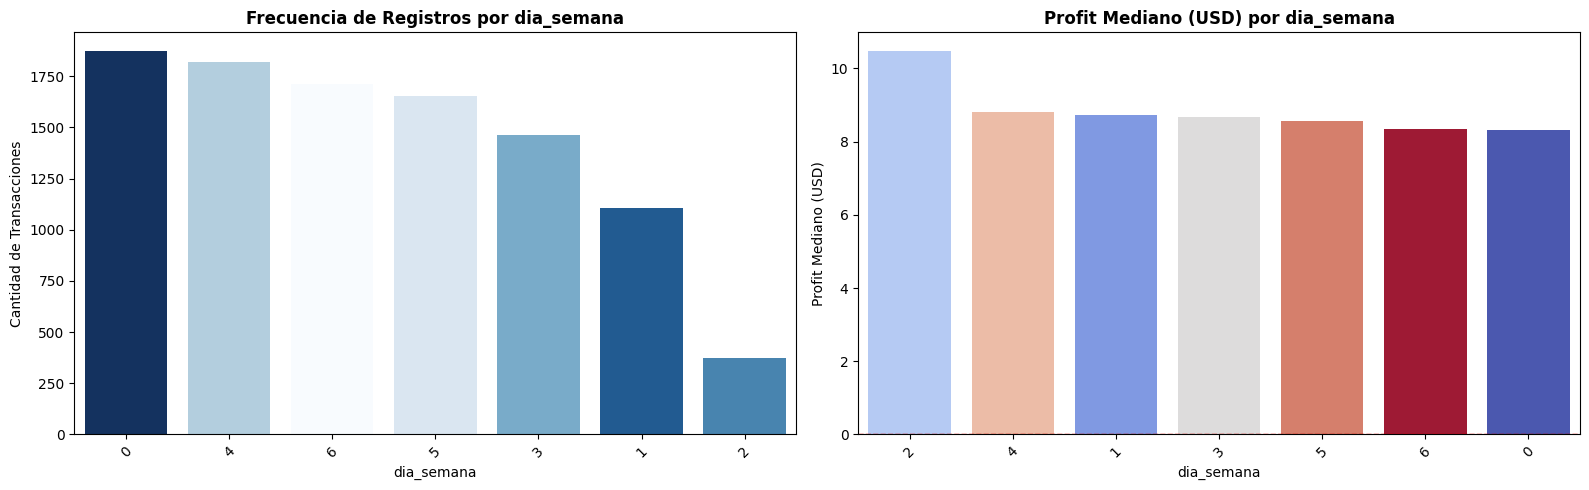

In [246]:
graficar_categorica_vs_profit(data, 'dia_semana')

Los días lunes, viernes y domingo lideran la cantidad de transacciones del dataset (alrededor de 1,700 a 1,850 registros cada uno), mientras que el día  miércoles registra el volumen operativo más bajo con menos de 400 ventas. En cuanto a la rentabilidad mediana, el comportamiento entre la mayoría de los días resulta homogéneo, manteniéndose en un rango de 8.3 a 8.8 USD por venta. La única excepción destacada la presenta el día miércoles, que encabeza el margen mediano alcanzando los ~10.5 USD por transacción, lo que demuestra que un menor volumen diario no compromete la eficiencia unitaria del negocio.

#### Análisis de la variable objetivo


Antes de transformar las variables analizamos la distribución de Profit, ya que la elección del escalado y, sobre todo, de la función de costo del MLP dependen de su forma. Nos interesa cuantificar:
- La proporción de transacciones con pérdida, lo que condiciona la función de activación de salida (debe poder devolver valores negativos).
- La asimetría, tipo de distribución y la cantidad de outliers según el criterio del rango intercuartílico.

In [247]:
resumen_profit = resumen_outliers_iqr(data, ['Profit'])
resumen_profit

,Variable,Media,Q1,Q2,Q3,Skewness,Kurtosis,Límite Inf,Límite Sup,Cant. Outliers,% Outliers
0,Profit,28.66,1.73,8.67,29.36,7.56,397.19,-39.72,70.82,1881,18.82%


In [248]:
limite_inferior = resumen_profit.loc[resumen_profit['Variable'] == 'Profit', 'Límite Inf'].values[0]
limite_superior = resumen_profit.loc[resumen_profit['Variable'] == 'Profit', 'Límite Sup'].values[0]
print(f'Registros con ganancias extremas: {len(data[data['Profit'] > limite_superior])}, Ganancias acumuladas: ${round(data[data['Profit'] > limite_superior]['Profit'].sum(),2)}')
print(f'Registros con pérdidas extremas: {len(data[data['Profit'] < limite_inferior])}, Pérdidas acumuladas: -${round(abs(data[data['Profit'] < limite_inferior]['Profit'].sum()),2)}')

Registros con ganancias extremas: 1277, Ganancias acumuladas: $332580.44
Registros con pérdidas extremas: 604, Pérdidas acumuladas: -$140327.36


**'Profit'** es una variable continua que presenta una distribución no normal, caracterizada por un sesgo pronunciado hacia la derecha (Skewness=7.56).

La masa principal de observaciones se concentra en valores positivos moderados, donde la mediana (Q2=8.67 USD) difiere de la media (28.66 USD), alcanzando un rango intercuartílico entre 1.73 y 29.36 USD. A diferencia de las variables predictivas anteriores, el dominio de Profit abarca tanto valores positivos como negativos [−6,600,+8,400], registrando 1,871 transacciones que generan pérdidas para el negocio.

Es una distribución leptocúrtica (Kurtosis = 397.19), lo que evidencia un pico muy pronunciado en el centro y colas pesadas en ambos extremos. El criterio IQR identifica 1,881 outliers (604 pérdidas extremas y 1,277 ganancias extremas) que corresponden a un ~19% de las observaciones.

Para poder visualizar nuestro análisis previo, recurrimos a dos histogramas, uno que muestra la distribución real y otro que muestra la distribución sin el efecto de los valores atípicos más extremos, así como también un boxplot en escala logarítmica simbólica para analizar los outliers.

Cabe destacar que se utilizó la escala logarítmica simbólica para poder visualizar correctamente el boxplot ya que, por los valores observados previamente en el análisis de outliers, sin utilizar esta escala, los outliers dominarían la escala de representación.

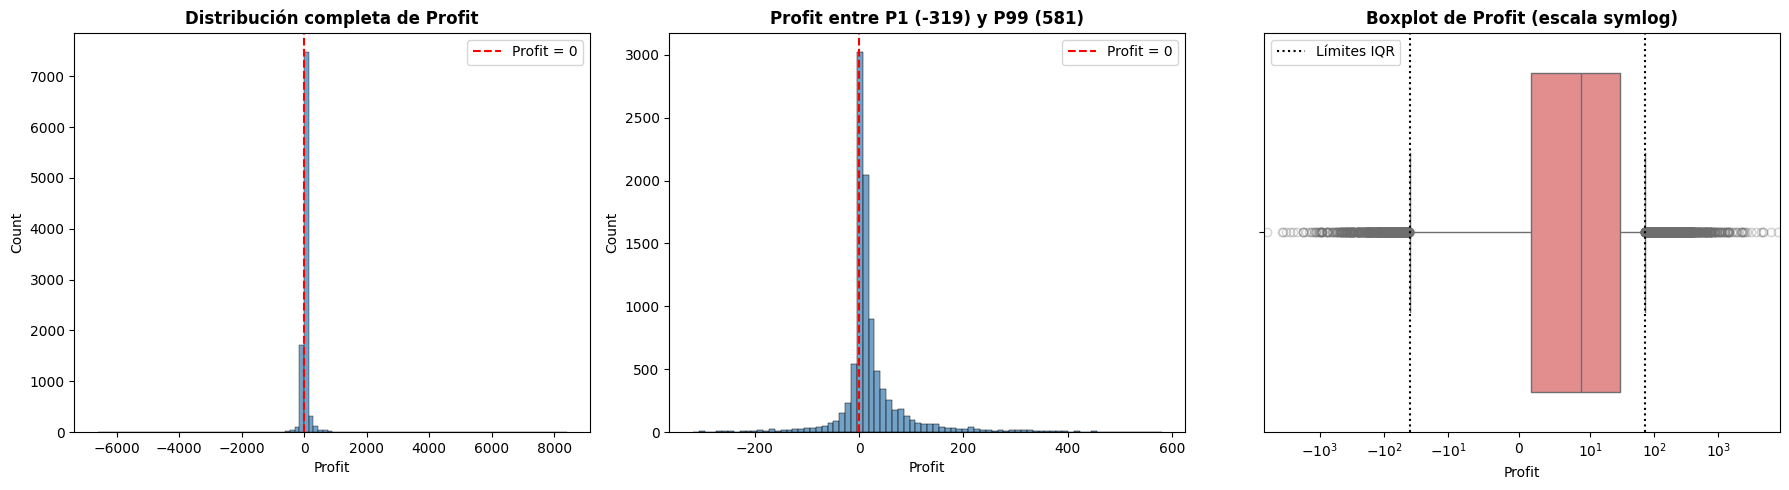

In [249]:
profit = data['Profit']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de la distribución completa
sns.histplot(profit, bins=100, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', label='Profit = 0')
axes[0].set_title('Distribución completa de Profit', fontweight='bold')
axes[0].legend()

# Histograma acotado a los percentiles 1 y 99
p01_profit, p99_profit = profit.quantile([0.01, 0.99])
sns.histplot(profit[profit.between(p01_profit, p99_profit)], bins=80, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', label='Profit = 0')
axes[1].set_title(f'Profit entre P1 ({p01_profit:.0f}) y P99 ({p99_profit:.0f})', fontweight='bold')
axes[1].legend()

# Boxplot en escala symlog con los límites IQR extraídos de la función
sns.boxplot(x=profit, ax=axes[2], color='lightcoral', flierprops=dict(marker='o', alpha=0.3))
axes[2].axvline(limite_inferior, color='black', linestyle=':', label='Límites IQR')
axes[2].axvline(limite_superior, color='black', linestyle=':')
axes[2].set_xscale('symlog', linthresh=10)
axes[2].set_title('Boxplot de Profit (escala symlog)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

La distribución completa refleja visualmente la distribución leptocúrtica antes mencionada. Debido al amplio rango [-6,600, +8,400], la mayoría de las transacciones se concentran en un único pico vertical denso en torno a cero.

La distribución acotada confirma que la lógica de negocio opera mayoritariamente con utilidades son pequeñas y positivas, aunque también presenta pérdidas observables en la cola izquierda de la distribución.

El boxplot permite observar la dispersión y alcance de los outliers. Aunque las observaciones atípicas son más numerosas hacia la derecha (ganancias), el margen izquierdo demuestra que las pérdidas individuales alcanzan magnitudes negativas considerablemente más severas. Esto se confirma con la observación anterior de pérdida y ganancia acumulada, teniendo en cuenta que 604 registros logran consolidar una pérdida de ~140mil dólares

### Train-Test Split

Se codificarán las variables 'mes', 'dia_semana' previo al Train-Test Split. La codificación cíclica nos permite, como su nombre indica, capturar la naturaleza cíclica de los meses del año y los días de la semana. Se puede realizar previo al train-test split porque se trata de una operación registro a registro, no recaba información o medidas resumen globales para el cálculo del valor asignado como ocurre con los escalados.

In [250]:
data = codificacion_ciclica(data, 'mes', 12, True)
data = codificacion_ciclica(data, 'dia_semana', 7, True)

Realizamos la división de nuestro dataset, dejando el 70% para Train, 20% para Test y 10% para Validación.

In [251]:
train_df, aux_df = train_test_split(
    data,
    test_size=0.3,
    shuffle=True,
    random_state=31
)

X_train = train_df.drop(columns=['Profit'])
y_train = train_df['Profit']

In [252]:
val_df, test_df = train_test_split(
    aux_df,
    test_size=20/30,
    shuffle=True,
    random_state=31
)

X_val = val_df.drop(columns=['Profit'])
y_val = val_df['Profit']
X_test = test_df.drop(columns=['Profit'])
y_test = test_df['Profit']

### Codificado y Escalado

Para el codificado y escalado, decidimos utilizar un pipeline de procesamiento para facilitar su aplicación luego en Test y Validación.
Como mencionamos previamente, realizamos un escalado robusto de las columnas numéricas (no cíclicas) y codificaremos el resto con One-Hot Encoding

In [253]:
num_cols = [
    'Sales', 'Quantity', 'Discount', 'dias_hasta_envio',
]
cat_cols = [
    'Ship Mode', 'Segment', 'State', 'Region',
    'Category', 'Sub-Category', 'anio', 'trimestre'
]
passthrough_cols = [
    'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
]

In [254]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('ciclicas', 'passthrough', passthrough_cols)
    ]
)

In [255]:
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)
X_val_prep = preprocesador.transform(X_val)

In [256]:
scaler_y = RobustScaler()
y_train_prep = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_prep  = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_prep = scaler_y.transform(y_test.values.reshape(-1, 1))

### Diseño e Implementación del MLP

#### Conversión a Tensores

Utilizamos PyTorch. Fijamos la semilla de Python, NumPy y PyTorch para que los experimentos sean reproducibles, y convertimos los conjuntos ya preprocesados a tensores float32 para asegurar la compatibilidad con las capas de entrada de PyTorch.

In [257]:
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [258]:
SEMILLA = 31
def fijar_semilla(semilla: int = SEMILLA):
    """Fija las semillas de Python, NumPy y PyTorch para garantizar reproducibilidad."""
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    torch.cuda.manual_seed_all(semilla)

fijar_semilla()

In [259]:
# Conversion de los conjuntos preprocesados a tensores float32
def a_tensor(arreglo):
    return torch.tensor(np.asarray(arreglo), dtype=torch.float32)

X_train_t, y_train_t = a_tensor(X_train_prep), a_tensor(y_train_prep)
X_val_t, y_val_t = a_tensor(X_val_prep), a_tensor(y_val_prep)
X_test_t, y_test_t = a_tensor(X_test_prep), a_tensor(y_test_prep)

print(f"Dispositivo: {dispositivo}")
print(f"Train: X {tuple(X_train_t.shape)} | y {tuple(y_train_t.shape)}")
print(f"Test:  X {tuple(X_test_t.shape)} | y {tuple(y_test_t.shape)}")
print(f"Val:   X {tuple(X_val_t.shape)} | y {tuple(y_val_t.shape)}")

Dispositivo: cpu
Train: X (6995, 86) | y (6995, 1)
Test:  X (2000, 86) | y (2000, 1)
Val:   X (999, 86) | y (999, 1)


Podemos observar que tenemos 95 características de entrada, el 70% de los datos está concentrado en Train, el 20% en Test y el último 10% en Validación.
A continuación haremos un desglose de la cantidad de features por tipo de variable.

In [260]:
#El preprocesador utiliza un patrón claro cuando genera prefijos para One-Hot Encoding, numéricas o cíclicas.
#Mediante un split podemos contabilizar cuantas características tenemos por prefijo
#y cuantas dimensiones añade cada variable categórica al pasar por un OHE.
nombres_features = preprocesador.get_feature_names_out()
conteo_por_tipo = {}
for nombre in nombres_features:
    prefijo = nombre.split('__')[0]
    conteo_por_tipo[prefijo] = conteo_por_tipo.get(prefijo, 0) + 1
print(f"Total de características de entrada: {len(nombres_features)}\n")
print("Desglose por transformador:")
for tipo, cantidad in conteo_por_tipo.items():
    print(f"  - {tipo}: {cantidad} columnas")
print("\n" + "="*50 + "\n")
ohe = preprocesador.named_transformers_['cat']
cats_originales = cat_cols
n_dummies_por_cat = [len(cats) for cats in ohe.categories_]
print("One-Hot Encoding por variable:")
for col, n in zip(cats_originales, n_dummies_por_cat):
    print(f"  - {col}: {n} dummies")
print(f"Total dummies: {sum(n_dummies_por_cat)}")

Total de características de entrada: 86

Desglose por transformador:
  - num: 4 columnas
  - cat: 78 columnas
  - ciclicas: 4 columnas


One-Hot Encoding por variable:
  - Ship Mode: 4 dummies
  - Segment: 3 dummies
  - State: 39 dummies
  - Region: 4 dummies
  - Category: 3 dummies
  - Sub-Category: 17 dummies
  - anio: 4 dummies
  - trimestre: 4 dummies
Total dummies: 78


#### Arquitectura del MLP

##### Justificaciones

**Capa de salida: Identity**

Al tratarse de un problema de regresión continua donde la variable objetivo Profit adopta valores continuos sin límite acotado, pudiendo tomar valores tanto positivos como negativos, no debe aplicarse ninguna restricción de rango a la salida de la última capa lineal. Funciones acotadas como Sigmoide o Tanh limitarían el rango de predicción, mientras que ReLU anularía las predicciones de valores negativos.

---

**Función de Costo**

La función de costo mide el error del modelo durante el entrenamiento para guiar la optimización.

MSE: Penaliza los errores de forma cuadrática. Dado que la variable Profit presenta una fuerte asimetría y presencia de outliers (aproximadamente 18.8% de observaciones atípicas con valores extremadamente altos o bajos), MSE produce gradientes desproporcionadamente elevados ante errores grandes. Esto inestabiliza el entrenamiento y hace que la red intente ajustarse a los valores atípicos a costa de degradar la precisión en las transacciones típicas.

**MAE:** Penaliza el error de forma lineal, siendo robusto ante valores atípicos. Sin embargo, su derivada no es continua en el origen, lo que genera oscilaciones e inestabilidad en la fase final de convergencia cerca del mínimo local.

**Huber Loss:** Combina las ventajas de MSE y MAE mediante un hiperparámetro de umbral (delta). Se comporta como MSE para errores pequeños, garantizando una convergencia suave y diferenciable cerca del origen, y como MAE para errores grandes, ofreciendo robustez frente a la cola pesada y los outliers de Profit.

Se realizará una comparación exhaustiva de los tres modelos para determinar cual es la más adecuada para la lógica de negocio.

---

**Estructura del MLP**

Red feedforward con 3 capas ocultas estructuradas en orden decreciente: (128, 64, 32) neuronas.

Tres capas ocultas otorgan la capacidad de representación suficiente para capturar las no linealidades complejas del dataset sin caer en sobreajuste masivo. La estructura cónica conocida como funnel o embudo (128 -> 64 -> 32) permite una extracción jerárquica de características. Las primeras capas capturan patrones generales del espacio transformado de entradas, reduciendo progresivamente la dimensionalidad hacia la representación final previa a la regresión.

Se utiliza ReLU como función de activación en capas ocultas por su eficiencia computacional y por mitigar el problema del desvanecimiento del gradiente

---

**Optimizador, Tasa de Aprendizaje y Estrategia de regularización**

Seleccionamos el optimizador Adam, que utiliza estimaciones adaptativas de momentos de primer y segundo orden. Es ideal para datos no lineales con gradientes ruidosos, logrando una convergencia más rápida y estable que el descenso de gradiente estocástico estándar.

Utilizamos una Taza de Aprendizaje de 0.001 estandar como punto de partida para el optimizador Adam.

Agregamos un scheduler ReduceLROnPlateau que monitorea la pérdida de validación y reduce la tasa de aprendizaje a la mitad (factor=0.5) tras 10 épocas sin mejora (patience=10). Esto permite dar pasos grandes al inicio del entrenamiento y refinarlos al aproximarse al mínimo local.

Definimos un Dropout de 0.2 como estrategia de regularización. Desactiva aleatoriamente el 20% de las neuronas en cada paso de entrenamiento dentro de las capas ocultas, evitando la coadaptación compleja de características y mejorando la capacidad de generalización.

Utilizamos Weight Decay o Regularización L2 ya que penaliza los pesos grandes en la función de pérdida para evitar un sobreajuste severo.

Nos valemos del Early Stopping (patience=25) para detener el entrenamiento si la pérdida de validación no mejora durante 25 épocas consecutivas y restaura los mejores pesos registrados, evitando la memorización del conjunto de entrenamiento.



In [261]:
class MLPRegresion(nn.Module):
    """MLP para regresión con capas ocultas ReLU + Dropout y salida lineal."""

    def __init__(self, n_entradas: int, capas_ocultas=(128, 64, 32), dropout: float = 0.2):
        super().__init__()
        capas = []
        n_anterior = n_entradas

        # Bloques ocultos: Linear -> ReLU -> Dropout
        for n_neuronas in capas_ocultas:
            capas += [nn.Linear(n_anterior, n_neuronas), nn.ReLU(), nn.Dropout(dropout)]
            n_anterior = n_neuronas
        # Capa de salida - identidad
        capas.append(nn.Linear(n_anterior, 1))
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x)


modelo_ejemplo = MLPRegresion(X_train_t.shape[1])
print(modelo_ejemplo)
print(f"\nParámetros entrenables: {sum(p.numel() for p in modelo_ejemplo.parameters() if p.requires_grad):,}")

MLPRegresion(
  (red): Sequential(
    (0): Linear(in_features=86, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros entrenables: 21,505


Podemos observar que tenemos 22,657 parámetros entrenables, lo que representa más de tres veces la cantidad de registros disponibles en el conjunto de entrenamiento. Dado que la red posee más parámetros que muestras, es propensa a memorizar los datos y sufrir overfitting, por lo que es necesario incorporar técnicas de regularización.

### Funciones de entrenamiento y evaluación

Como mencionamos antes, para el proceso de entrenamiento decidimos utilizar el optimizador Adam con una tasa de aprendizaje inicial de 10^(-3), ya que adapta el aprendizaje parámetro a parámetro y resulta útil frente a gradientes con escalas dispares provocados por los valores atípicos de Profit.

Trabajamos con mini-batches de 64 muestras y combinamos regularización por Dropout, penalización L2 a través de weight_decay y Early Stopping con una paciencia de 25 épocas para cortar el entrenamiento y restaurar los mejores pesos cuando la pérdida en validación deje de mejorar.

Agregamos un scheduler que reduce el Learning Rate para asegurarnos de minimizar la pérdida al achicar los pasos en el proceso de decenso de gradiente. Definimos una paciencia de 10 épocas sin mejora, estrictamente menor a la del Early Stopping.

Finalmente, todas las predicciones y métricas de error se evalúan directamente en dólares, revirtiendo el escalado de la variable objetivo con scaler_y para poder comparar justamente el desempeño entre las distintas funciones de costo e interpretar el impacto real de las predicciones en el negocio.

In [262]:
def entrenar_modelo(modelo, funcion_costo, X_tr, y_tr, X_va, y_va, epocas=300, tam_lote=64,
                    lr=1e-3, weight_decay=1e-4, paciencia=25, semilla=SEMILLA):
    """Entrena el modelo con Adam, ReduceLROnPlateau y Early Stopping."""

    # DataLoader con generador fijo para reproducibilidad
    generador = torch.Generator().manual_seed(semilla)
    cargador = DataLoader(TensorDataset(X_tr, y_tr), batch_size=tam_lote, shuffle=True, generator=generador)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # Inicializamos el Scheduler
    scheduler = ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

    modelo.to(dispositivo)
    X_va, y_va = X_va.to(dispositivo), y_va.to(dispositivo)
    historial = {'train': [], 'val': [], 'lr': []}
    mejor_perdida_val, mejor_estado, epocas_sin_mejora = float('inf'), None, 0

    for epoca in range(epocas):
        #Fase de Entrenamiento
        modelo.train()
        perdida_acumulada = 0.0
        for X_lote, y_lote in cargador:
            X_lote, y_lote = X_lote.to(dispositivo), y_lote.to(dispositivo)
            optimizador.zero_grad()
            perdida = funcion_costo(modelo(X_lote), y_lote)
            perdida.backward()
            optimizador.step()

            # Ponderamos por el tamaño real del lote
            perdida_acumulada += perdida.item() * len(X_lote)

        perdida_train_promedio = perdida_acumulada / len(cargador.dataset)
        historial['train'].append(perdida_train_promedio)

        # Fase de Validación
        modelo.eval()
        with torch.no_grad():
            perdida_val = funcion_costo(modelo(X_va), y_va).item()
        historial['val'].append(perdida_val)

        # Guardamos el Learning Rate actual en el historial
        lr_actual = optimizador.param_groups[0]['lr']
        historial['lr'].append(lr_actual)

        # Actualización del Scheduler
        scheduler.step(perdida_val)

        # Early Stopping
        if perdida_val < mejor_perdida_val - 1e-6:
            mejor_perdida_val = perdida_val
            mejor_estado = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= paciencia:
                break

    # Cargar los mejores pesos encontrados
    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    historial['mejor_epoca'] = int(np.argmin(historial['val'])) + 1
    return modelo, historial


def predecir_dolares(modelo, X_t):
    """Predice y revierte el escalado de y para obtener el Profit en dólares."""
    modelo.eval()
    with torch.no_grad():
        prediccion_escalada = modelo(X_t.to(dispositivo)).cpu().numpy()
    return scaler_y.inverse_transform(prediccion_escalada).ravel()


def metricas_dolares(y_real, y_pred):
    """MAE, RMSE y R^2 calculados en la escala original (dólares)."""
    return {
        'MAE (USD)': mean_absolute_error(y_real, y_pred),
        'RMSE (USD)': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R^2': r2_score(y_real, y_pred),
    }

### Comparación de funciones de costo

Entrenamos la misma arquitectura, con la misma inicialización de pesos, reiniciando la semilla, y los mismos hiperparámetros, variando únicamente la función de costo. La comparación se hace sobre validación; el conjunto de test se reserva para la evaluación final del modelo elegido.

#### Entrenamiento del MLP

In [263]:
funciones_costo = {
    'MSE': nn.MSELoss(),
    'MAE': nn.L1Loss(),
    'Huber (δ=1)': nn.HuberLoss(delta=1.0),
}

resultados_costo, historiales_costo, modelos_costo, predicciones_val = [], {}, {}, {}

for nombre_costo, funcion_costo in funciones_costo.items():
    # Misma semilla -> misma inicializacion de pesos para una comparacion justa
    fijar_semilla()
    modelo = MLPRegresion(X_train_t.shape[1])
    modelo, historial = entrenar_modelo(modelo, funcion_costo, X_train_t, y_train_t, X_val_t, y_val_t)

    # Metricas en dolares sobre validacion
    prediccion_val = predecir_dolares(modelo, X_val_t)
    resultados_costo.append({
        'Función de costo': nombre_costo,
        'Épocas entrenadas': len(historial['train']),
        'Mejor época': historial['mejor_epoca'],
        **metricas_dolares(y_val.values, prediccion_val),
    })
    historiales_costo[nombre_costo] = historial
    modelos_costo[nombre_costo] = modelo
    predicciones_val[nombre_costo] = prediccion_val
    print(f"{nombre_costo}: entrenamiento finalizado en {len(historial['train'])} épocas")

tabla_costos = pd.DataFrame(resultados_costo).set_index('Función de costo').round(3)
print()
print(tabla_costos)

MSE: entrenamiento finalizado en 123 épocas
MAE: entrenamiento finalizado en 75 épocas
Huber (δ=1): entrenamiento finalizado en 74 épocas

                  Épocas entrenadas  Mejor época  MAE (USD)  RMSE (USD)    R^2
Función de costo                                                              
MSE                             123           98     20.397      49.451  0.899
MAE                              75           50     15.966      41.842  0.928
Huber (δ=1)                      74           49     16.379      41.738  0.928


Huber y MAE superan claramente a MSE tanto en precisión como en velocidad de convergencia, siendo Huber la función de costo óptima para este modelo al lograr el menor RMSE, el R^2 más alto y el menor tiempo de entrenamiento.

#### Funciones útiles

Utilizaremos esta función para graficar la pérdida de entrenamiento y validación por época para cada función de costo.

In [264]:
def graficar_historial(historial):
    """
    Grafica la evolución de las pérdidas de Entrenamiento/Validación
    y la variación del Learning Rate a lo largo de las épocas.
    """
    epocas = range(1, len(historial['train']) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Eje Izquierdo: Pérdida
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida (Loss)', color='black')
    linea_train = ax1.plot(epocas, historial['train'], label='Train Loss', color='#1f77b4', linewidth=2)
    linea_val = ax1.plot(epocas, historial['val'], label='Val Loss', color='#ff7f0e', linewidth=2)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Línea vertical en la mejor época
    linea_mejor = []
    if 'mejor_epoca' in historial:
        linea_mejor = [ax1.axvline(
            historial['mejor_epoca'], color='red', linestyle=':',
            label=f"Mejor Época ({historial['mejor_epoca']})"
        )]

    # Eje Derecho: Learning Rate
    ax2 = ax1.twinx()
    ax2.set_ylabel('Learning Rate', color='#2ca02c')
    linea_lr = ax2.plot(epocas, historial['lr'], label='Learning Rate', color='#2ca02c', linestyle='--', linewidth=2)
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor='#2ca02c')

    # Unificar las leyendas de ambos ejes
    lineas = linea_train + linea_val + linea_lr + linea_mejor
    etiquetas = [l.get_label() for l in lineas]
    ax1.legend(lineas, etiquetas, loc='center right')

    plt.title('Evolución de Entrenamiento y ReduceLROnPlateau')
    plt.tight_layout()
    plt.show()


#### MSE

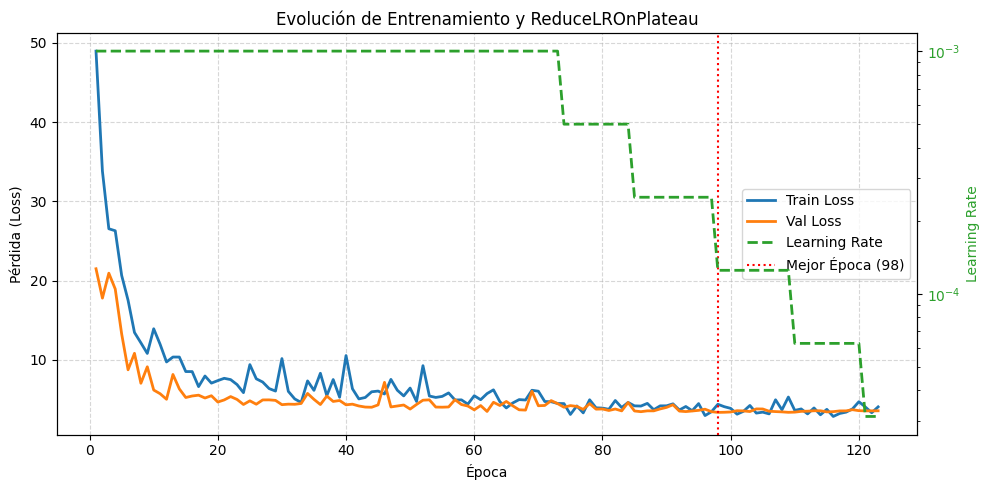

In [265]:
graficar_historial(historiales_costo['MSE'])

Podemos observar que el modelo empieza a converger a partir de la época 50, nos da una idea que el conjunto de datos puede ser procesado con pocas . En tanto al Learning Rate podemos observar cinco reducciones a lo largo del entrenamiento, conforme se va reduciendo, se reduce el ruido entre las curvas de aprendizaje y entrenamiento. Tanto la curva de aprendizaje como la de pérdida nunca divergen lo que sugiere que no tenemos un caso de overfitting.

#### MAE

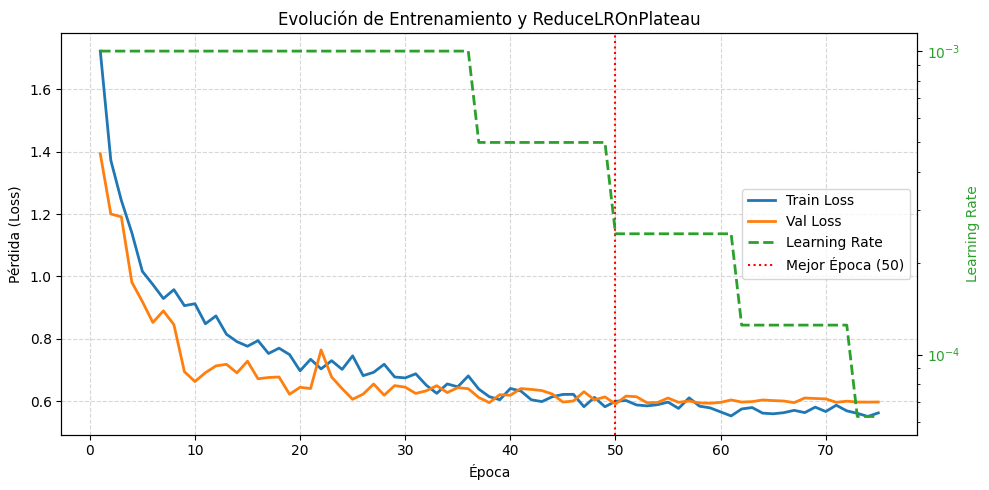

In [266]:
graficar_historial(historiales_costo['MAE'])

Podemos observar claramente que el error relativo comienza de un punto muchísimo menor comparado con el MSE. La convergencia se dá a partir de la época 30 aproximadamente, cortando finalmente en la época 50. De haber seguido se habría sobreajustado, al ver que la perdida en validación crece por sobre la pérdida de entrenamiento.

#### Huber Loss

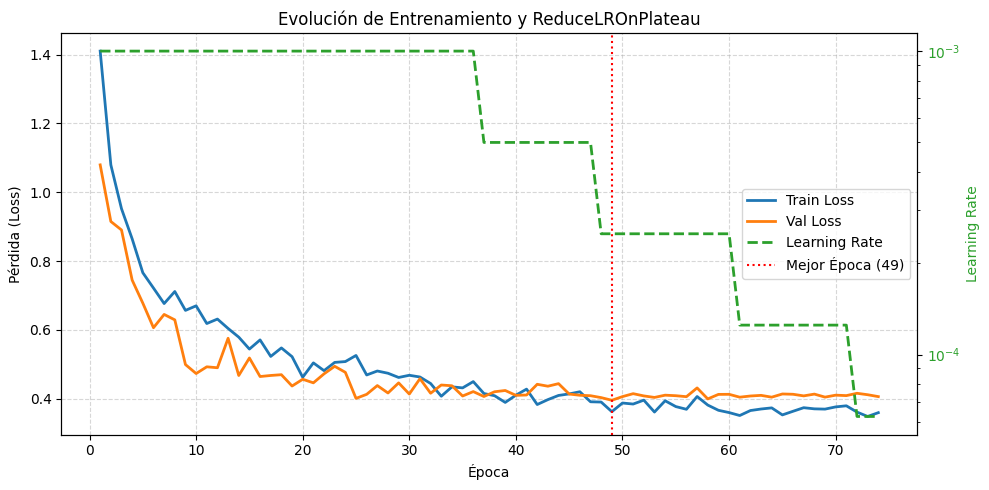

In [267]:
graficar_historial(historiales_costo['Huber (δ=1)'])

Observamos un comportamiento similar a la gráfica de pérdida del MAE. Convergen alrededor de la misma época, sus mejores épocas son cercanas y comienzan a sobreajustarse en épocas similares.

#### Métricas en Test

Para poder evaluar realmente nuestros modelos utilizar nuestro conjunto de test. Observaremos las métricas clave para los modelos de regresión MSE, RMSE y R^2 y a partir de ellas seleccionaremos el mejor modelo.

In [268]:
resultados_test = []

# Evaluamos cada uno de los modelos entrenados en el conjunto de Test
for nombre_costo, modelo in modelos_costo.items():
    # Predicción y desescalado a dólares
    y_test_pred = predecir_dolares(modelo, X_test_t)
    y_test_real = y_test.values

    # Cálculo de métricas
    metricas = metricas_dolares(y_test_real, y_test_pred)

    # Guardamos los resultados
    resultados_test.append({
        'Función de costo': nombre_costo,
        'MAE (USD)': metricas['MAE (USD)'],
        'RMSE (USD)': metricas['RMSE (USD)'],
        'R^2': metricas['R^2']
    })

# Creamos un DataFrame ordenado por R^2 de mayor a menor
tabla_test = pd.DataFrame(resultados_test).sort_values(by='R^2', ascending=False).reset_index(drop=True)

# Imprimimos la tabla comparativa
print("="*60)
print("     EVALUACIÓN COMPARATIVA EN CONJUNTO DE TEST")
print("="*60)
print(tabla_test.to_string(index=False, formatters={
    'MAE (USD)': '${:,.2f}'.format,
    'RMSE (USD)': '${:,.2f}'.format,
    'R^2': '{:.4f}'.format
}))
print("="*60)

     EVALUACIÓN COMPARATIVA EN CONJUNTO DE TEST
Función de costo MAE (USD) RMSE (USD)    R^2
             MSE    $25.30    $161.75 0.7242
     Huber (δ=1)    $24.16    $166.21 0.7087
             MAE    $24.48    $189.10 0.6230


Observando los valores de RMSE obtenidos, queda en evidencia que el conjunto de Test contiene valores atípicos de gran magnitud. En entrenamiento observábamos valores de 41 a 49 dólares contra los 161 a 189 dólares de la evaluación en el conjunto de test.

A nivel entrenamiento, el MLP entrenado con la función de costo MSE presentaba peor perfomance que el resto. En test, teniendo en cuenta la presencia de valores atípicos grandes, tiene sentido que sea el modelo que mejor R^2 y RMSE presenta, ya que la función de costo misma penaliza los errores al cuadrado. Analizando el R^2, nuestro modelo explica el ~72% de la variabilidad de los datos observados en test.

Huber, por su parte, actúa como una combinación de MSE y MAE. Penaliza los residuos menores al delta de manera cuadrática y los mayores de manera lineal. Sirve para problemas donde los modelos requieran penalizar los errores pequeños y no sobre-penalizar los grandes. Teniendo esto en cuenta, en los resultados de test Huber obtiene el mejor MAE del conjunto de evaluación (24.16 USD), mientras conserva un buen desempeño global frente a desviaciones grandes. Analizando el valor de R^2, nuestro modelo explica el ~71% de la variabilidad de los datos observados en test.

Finalmente, la penalización lineal por parte del modelo entrenado con la función de costo MAE hace que no pueda adaptarse correctamente a los datos de test debido a la presencia de outliers.

#### Gráficos de Dispersión

#### Valor Real vs. Predicho

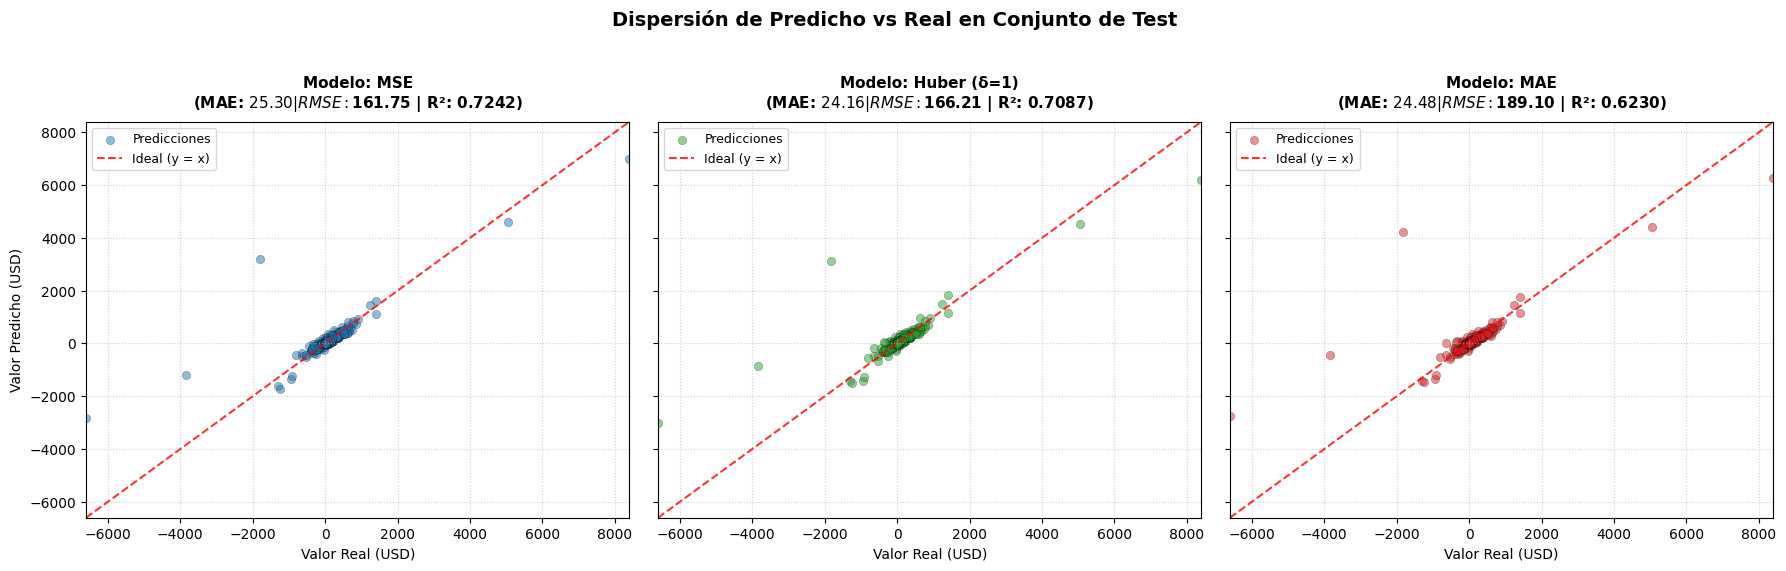

In [269]:
y_pred_mse = predecir_dolares(modelos_costo['MSE'], X_test_t)
y_pred_huber = predecir_dolares(modelos_costo['Huber (δ=1)'], X_test_t)
y_pred_mae = predecir_dolares(modelos_costo['MAE'], X_test_t)
y_test = y_test.values

models_data = [
    ("MSE", y_pred_mse, "#1f77b4", "MAE: $25.30 | RMSE: $161.75 | R²: 0.7242"),
    ("Huber (δ=1)", y_pred_huber, "#2ca02c", "MAE: $24.16 | RMSE: $166.21 | R²: 0.7087"),
    ("MAE", y_pred_mae, "#d62728", "MAE: $24.48 | RMSE: $189.10 | R²: 0.6230")
]

# Configuración de los ejes límites para que los 3 gráficos mantengan la misma escala
all_preds = np.concatenate([y_pred_mse, y_pred_huber, y_pred_mae])
min_val = min(np.min(y_test), np.min(all_preds))
max_val = max(np.max(y_test), np.max(all_preds))

# Crear la figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax, (name, y_pred, color, metrics) in zip(axes, models_data):
    # Gráfico de dispersión (Valores Reales vs Predichos)
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='k', linewidths=0.3, label="Predicciones")

    # Línea ideal y = x (Predicción perfecta)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y = x)', alpha=0.8)

    ax.set_title(f"Modelo: {name}\n({metrics})", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Valor Real (USD)", fontsize=10)
    if name == "MSE":
        ax.set_ylabel("Valor Predicho (USD)", fontsize=10)

    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

plt.suptitle("Dispersión de Predicho vs Real en Conjunto de Test", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Las gráficas se corresponden con lo analizado anteriormente.

El modelo MSE penaliza fuertemente los outliers, acercándolos al valor real.

Huber es el representa el equilibrio entre MSE y MAE.

MAE penaliza linealmente los outliers, alejándolos de gran manera del valor real.

Podemos observar que la tendencia de los residuos en los tres gráficos es lineal, solamente varía la forma de penalización de outliers.

#### Residuos vs. Predicho

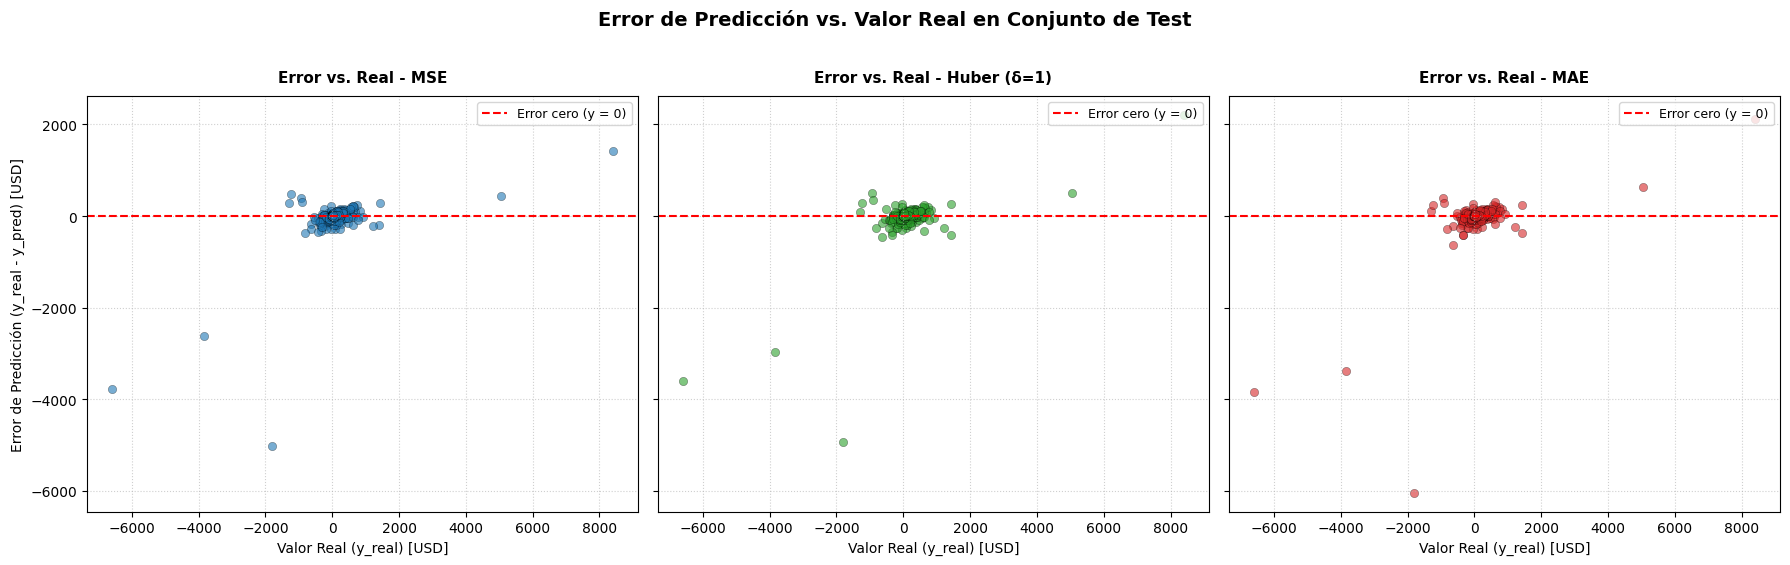

In [270]:
modelos = {
    "MSE": y_pred_mse,
    "Huber (δ=1)": y_pred_huber,
    "MAE": y_pred_mae
}

colores = {
    "MSE": "#1f77b4",
    "Huber (δ=1)": "#2ca02c",
    "MAE": "#d62728"
}

# 1. Graficar Error vs y_real para los 3 modelos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

df_errores_todos = {}

for ax, (nombre, y_pred) in zip(axes, modelos.items()):
    # Crear DataFrame por modelo
    df_temp = pd.DataFrame({
        'Modelo': nombre,
        'y_real': y_test,
        'y_pred': y_pred,
        'error': y_test - y_pred,
        'error_abs': np.abs(y_test - y_pred)
    })
    df_errores_todos[nombre] = df_temp

    # Graficar
    ax.scatter(df_temp['y_real'], df_temp['error'], alpha=0.6, color=colores[nombre], edgecolors='k', linewidths=0.3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Error cero (y = 0)')

    ax.set_title(f"Error vs. Real - {nombre}", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Valor Real (y_real) [USD]", fontsize=10)
    if nombre == "MSE":
        ax.set_ylabel("Error de Predicción (y_real - y_pred) [USD]", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle("Error de Predicción vs. Valor Real en Conjunto de Test", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



Los tres gráficos muestran una dispersion homogenea alrededor del (0,0) con algunos casos de error correspondientes a valores atípicos de la variable objetivo en test.

Viendo de cerca estos casos atípicos, podemos determinar que nuestros modelos tienden a sub-estimar los outliers positivos.

En los casos negativos, podemos observar una instancia de sobre-estimación donde el valor real es cercano a -2000 USD y el error asociado entre -5000 y -6000 USD aproximadamente. Los otros outliers visibles, en comparación, fueron sub-estimados.

Podemos concluir, entonces, que nuestros tres modelos fallan en pedidos de gran magnitud.

In [271]:
# Extraer y agrupar los 5 peores casos de cada modelo
print("="*80)
print("TOP 5 CASOS CON MAYOR ERROR ABSOLUTO POR MODELO")
print("="*80)

top5_consolidadas = []

for nombre, df in df_errores_todos.items():
    top5 = df.sort_values(by='error_abs', ascending=False).head(5)
    top5_consolidadas.append(top5)

    print(f"\nMODELO: {nombre}")
    print(top5[['y_real', 'y_pred', 'error', 'error_abs']].to_string(index=True))

# Tabla general combinada
df_top5_final = pd.concat(top5_consolidadas, axis=0)

TOP 5 CASOS CON MAYOR ERROR ABSOLUTO POR MODELO

MODELO: MSE
         y_real       y_pred        error    error_abs
44   -1811.0784  3209.922607 -5021.001007  5021.001007
273  -6599.9780 -2825.621826 -3774.356174  3774.356174
1727 -3839.9904 -1210.688843 -2629.301557  2629.301557
977   8399.9760  6979.725098  1420.250902  1420.250902
473  -1237.8462 -1713.108276   475.262076   475.262076

MODELO: Huber (δ=1)
         y_real       y_pred        error    error_abs
44   -1811.0784  3134.411621 -4945.490021  4945.490021
273  -6599.9780 -2995.873047 -3604.104953  3604.104953
1727 -3839.9904  -861.819336 -2978.171064  2978.171064
977   8399.9760  6188.925781  2211.050219  2211.050219
960   5039.9856  4541.289551   498.696049   498.696049

MODELO: MAE
         y_real       y_pred        error    error_abs
44   -1811.0784  4231.189453 -6042.267853  6042.267853
273  -6599.9780 -2753.552002 -3846.425998  3846.425998
1727 -3839.9904  -451.895050 -3388.095350  3388.095350
977   8399.9760  6272.066

Confirmamos lo teorizado anteriormente, el outlier con ID 44 fue sobre-estimado por los tres modelos siendo el modelo MAE el que más lo sobreestimó.

Para todos los otros valores extremos, los modelos tienden a subestimar.

A su vez, reforzamos que el modelo MSE es el que mayormente penalizó estos errores.

In [272]:
df_top5_final.groupby(by='Modelo')['error_abs'].sum()

,error_abs
Modelo,
Huber (δ=1),14237.512306
MAE,16039.133058
MSE,13320.171717


Podemos observar que el modelo MSE presenta un menor error absoluto en relación al resto, por lo que logró mitigar los casos atípicos mejor que el resto.

### Análisis y Conclusiones

#### Selección final del modelo

La elección del modelo final se basó en la versión entrenada con Huber Loss debido a su alineación directa con la lógica de negocio del dataset. En un entorno comercial de retail, la gran mayoría de las operaciones corresponden a transacciones cotidianas de margen moderado, mientras que los valores extremos de Profit representan casos excepcionales como grandes pedidos corporativos o devoluciones atípicas. Utilizar un modelo enfocado en MSE habría forzado a la red a desviar sus predicciones para intentar capturar estos eventos aislados, sacrificando la precisión en la operación diaria. Huber Loss permite proteger al modelo frente al ruido de estos outliers extremos y, al mismo tiempo, mantener un ajuste preciso y confiable para la masa principal de transacciones que sostiene el flujo habitual del negocio.

#### Limitaciones

El entrenamiento y ajuste de una Red Neuronal Multicapa implica un costo computacional considerablemente mayor que el de modelos tradicionales. Requiere una fase de preprocesamiento efectiva, búsquedas de hiperparámetros complejas y un proceso iterativo de optimización basado en propagación hacia atrás con uso intensivo de CPU/GPU.

Teniendo en cuenta el procesamiento, una de las limitaciones es el uso de One-Hot Encoding para variables de alta cardinalidad ya que incrementa drásticamente la dimensionalidad del espacio de entrada, produciendo matrices dispersas que dificultan la extracción eficiente de características por parte de las capas lineales iniciales.

A diferencia de un modelo lineal o un árbol de decisión, el MLP no permite identificar fácilmente el impacto directo o la contribución marginal de cada variable comercial sobre el resultado final de Profit.

No se justifica el uso de un MLP en este caso ya que existen mejores alternativas como Ensemble Learning. Estos resuelven la mayoría de las limitaciones observadas a través del desarrollo de este trabajo práctico.

Manejan de forma nativa variables categóricas de alta cardinalidad y relaciones no lineales complejas sin requerir escalados estrictos. Son más robustos ante la presencia de outliers y datos sesgados en la variable objetivo y requieren un costo de entrenamiento significativamente menor sin sacrificar performance.

#### Mejoras

Como propuesta de mejora para el modelo, se plantea reemplazar el ajuste manual de hiperparámetros por una optimización bayesiana sistemática utilizando la librería Optuna. Esta técnica permitiría explorar eficientemente el espacio de búsqueda para definir la combinación óptima de número de capas, tasa de aprendizaje, tamaño de lote y parámetros de regularización como dropout y weight decay.

Otra mejora relevante consiste en implementar Entity Embeddings para las variables categóricas, reemplazando el esquema tradicional de One-Hot Encoding. Al aprender representaciones vectoriales continuas para variables como State, Sub-Category y Region, se reduciría la dimensionalidad de la matriz de entrada. Esto facilitaría que la red identifique relaciones semánticas complejas y similitudes continuas entre las distintas categorías.

Por último, para resolver la opacidad del modelo y evaluar su explicabilidad, se propone integrar la librería SHAP. Mediante este enfoque es posible determinar el aporte específico de cada variable sobre las predicciones de Profit, diferenciando cuáles impulsaron el resultado hacia ganancias o pérdidas. Además, permite generar un ranking global de importancia de características y analizar la dirección de su impacto en el margen operativo.